# Group Details

Group name: Group 07

Project: Financial Transaction Analysis

Group members: -

1) GOYAL TARUCHIT TARUN CHITRA : 2022DC04496

2) DEVENDRA KUMAR SINGH CHAUHAN : 2021SC04399

3) JAYKUMAR CHAUDHARY : 2022DC04341

4) PRANITA CHAUDHARY : 2022DC04500

# Importing of libraries

In [1]:
#Importing of libraries
import numpy as np #It is used for scientific computing
import pandas as pd #It is used for data wrangling and analysis
#It enables to show figures directly in the browser
%matplotlib inline
import matplotlib.pyplot as plt #It is used to plot visualizations using Matplotlib library
import seaborn as sns #It is used to plot visualization using Seaborn library

# Reading the dataset

In [2]:
#Reading the dataset
financial_data=pd.read_csv("Group7_FinancialTransactions.csv")

#Creating a copy of original dataset incase later required
financial_data_original=pd.read_csv("Group7_FinancialTransactions.csv")

# Sanity check of dataset

In [3]:
#Printing top two rows of the dataset for sanity check
financial_data.head(2)

,Unnamed: 0,Amount,Date,Card Type,MCC Category,Location,Device,Previous Transactions,Balance Before Transaction,Time of Day,Velocity,Customer Age,Customer Income,Card Limit,Credit Score,Merchant Reputation,Merchant Location History,Spending Patterns,Online Transactions Frequency,Is Fraudulent
0,0,180.924993,2023-07-02,Debit,Electronics,UK,Desktop,6,919.055267,10,-0.337955,52,105545.340543,2503.758986,401,Average,6,828.820298,Medium,0
1,1,794.625797,2023-02-18,Prepaid,Groceries,Canada,Desktop,5,3529.930762,17,0.015117,62,92651.854405,12885.681726,409,Average,13,4384.528307,Low,1


In [4]:
#Printing last two rows of the dataset for sanity check
financial_data.tail(2)

,Unnamed: 0,Amount,Date,Card Type,MCC Category,Location,Device,Previous Transactions,Balance Before Transaction,Time of Day,Velocity,Customer Age,Customer Income,Card Limit,Credit Score,Merchant Reputation,Merchant Location History,Spending Patterns,Online Transactions Frequency,Is Fraudulent
998,998,517.723900,2023-11-25,Debit,Entertainment,US,POS,8,496.330227,4,0.331765,21,65820.723836,15900.001061,529,Good,6,814.016929,Low,0
999,999,489.865943,2023-11-09,Debit,Electronics,US,Desktop,0,4015.643994,13,0.109080,71,127303.531382,14111.272226,542,Average,7,1311.880140,Medium,0


In [5]:
#Fetching list of all columns
financial_data.columns

Index(['Unnamed: 0', 'Amount', 'Date', 'Card Type', 'MCC Category', 'Location',
       'Device', 'Previous Transactions', 'Balance Before Transaction',
       'Time of Day', 'Velocity', 'Customer Age', 'Customer Income',
       'Card Limit', 'Credit Score', 'Merchant Reputation',
       'Merchant Location History', 'Spending Patterns',
       'Online Transactions Frequency', 'Is Fraudulent'],
      dtype='object')

In [6]:
#Renaming of columns to replace spaces with underscore and thus making the column names easy to use and readable
financial_data.columns=financial_data.columns.str.replace(" ","_")
financial_data.columns

Index(['Unnamed:_0', 'Amount', 'Date', 'Card_Type', 'MCC_Category', 'Location',
       'Device', 'Previous_Transactions', 'Balance_Before_Transaction',
       'Time_of_Day', 'Velocity', 'Customer_Age', 'Customer_Income',
       'Card_Limit', 'Credit_Score', 'Merchant_Reputation',
       'Merchant_Location_History', 'Spending_Patterns',
       'Online_Transactions_Frequency', 'Is_Fraudulent'],
      dtype='object')

In [7]:
#Dropping first column from the dataset
financial_data=financial_data.drop(financial_data.columns[[0]],axis=1)
financial_data.columns

Index(['Amount', 'Date', 'Card_Type', 'MCC_Category', 'Location', 'Device',
       'Previous_Transactions', 'Balance_Before_Transaction', 'Time_of_Day',
       'Velocity', 'Customer_Age', 'Customer_Income', 'Card_Limit',
       'Credit_Score', 'Merchant_Reputation', 'Merchant_Location_History',
       'Spending_Patterns', 'Online_Transactions_Frequency', 'Is_Fraudulent'],
      dtype='object')

In [8]:
financial_data.head()

,Amount,Date,Card_Type,MCC_Category,Location,Device,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Reputation,Merchant_Location_History,Spending_Patterns,Online_Transactions_Frequency,Is_Fraudulent
0,180.924993,2023-07-02,Debit,Electronics,UK,Desktop,6,919.055267,10,-0.337955,52,105545.340543,2503.758986,401,Average,6,828.820298,Medium,0
1,794.625797,2023-02-18,Prepaid,Groceries,Canada,Desktop,5,3529.930762,17,0.015117,62,92651.854405,12885.681726,409,Average,13,4384.528307,Low,1
2,818.413303,2023-01-02,Prepaid,Electronics,UK,POS,5,6578.889931,4,-0.198457,42,90579.479280,2039.105869,323,Good,1,733.282224,High,0
3,530.306522,2023-03-21,Credit,Restaurants,US,Mobile,3,8036.856328,20,-0.076741,76,63777.184316,5568.880208,674,Bad,1,670.074148,High,0
4,649.101853,2023-08-28,Debit,Electronics,Canada,Desktop,4,5342.795887,16,-0.029077,39,30620.998085,6945.439545,533,Good,3,550.619875,Low,0


# Checking if target class is imbalanced

<Axes: >

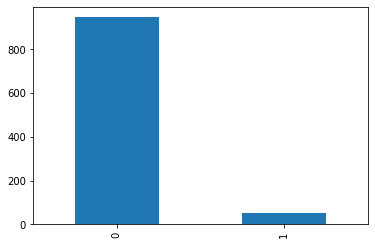

In [9]:
#Plotting the visualization to check distribution of target class
financial_data['Is_Fraudulent'].value_counts().plot(kind='bar')

In [10]:
financial_data['Is_Fraudulent'].value_counts(normalize=True)

0    0.947
1    0.053
Name: Is_Fraudulent, dtype: float64

We observed class imbalance issue exists in our dataset. 
That is, for field Is_Fraudulent, label=0 has very high count in frequency as compared to label=1.

94.7% records have label=0 and 5.3% records have label=1

Thus, there is discrimintaion of class labels in the dataset.

In [11]:
financial_data.head()

,Amount,Date,Card_Type,MCC_Category,Location,Device,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Reputation,Merchant_Location_History,Spending_Patterns,Online_Transactions_Frequency,Is_Fraudulent
0,180.924993,2023-07-02,Debit,Electronics,UK,Desktop,6,919.055267,10,-0.337955,52,105545.340543,2503.758986,401,Average,6,828.820298,Medium,0
1,794.625797,2023-02-18,Prepaid,Groceries,Canada,Desktop,5,3529.930762,17,0.015117,62,92651.854405,12885.681726,409,Average,13,4384.528307,Low,1
2,818.413303,2023-01-02,Prepaid,Electronics,UK,POS,5,6578.889931,4,-0.198457,42,90579.479280,2039.105869,323,Good,1,733.282224,High,0
3,530.306522,2023-03-21,Credit,Restaurants,US,Mobile,3,8036.856328,20,-0.076741,76,63777.184316,5568.880208,674,Bad,1,670.074148,High,0
4,649.101853,2023-08-28,Debit,Electronics,Canada,Desktop,4,5342.795887,16,-0.029077,39,30620.998085,6945.439545,533,Good,3,550.619875,Low,0


# Checking for null values in the dataset

In [12]:
#Checking for null values in the dataset
financial_data.isnull().sum()

Amount                           0
Date                             0
Card_Type                        0
MCC_Category                     0
Location                         0
Device                           0
Previous_Transactions            0
Balance_Before_Transaction       0
Time_of_Day                      0
Velocity                         0
Customer_Age                     0
Customer_Income                  0
Card_Limit                       0
Credit_Score                     0
Merchant_Reputation              0
Merchant_Location_History        0
Spending_Patterns                0
Online_Transactions_Frequency    0
Is_Fraudulent                    0
dtype: int64

In [13]:
financial_data.isna().sum()

Amount                           0
Date                             0
Card_Type                        0
MCC_Category                     0
Location                         0
Device                           0
Previous_Transactions            0
Balance_Before_Transaction       0
Time_of_Day                      0
Velocity                         0
Customer_Age                     0
Customer_Income                  0
Card_Limit                       0
Credit_Score                     0
Merchant_Reputation              0
Merchant_Location_History        0
Spending_Patterns                0
Online_Transactions_Frequency    0
Is_Fraudulent                    0
dtype: int64

We do not find any null values in the dataset across all fields.

# Univariate analysis

In [14]:
#Fetching the data type of each field in the dataset to understand what type of operations can be performed over them.
financial_data.dtypes

Amount                           float64
Date                              object
Card_Type                         object
MCC_Category                      object
Location                          object
Device                            object
Previous_Transactions              int64
Balance_Before_Transaction       float64
Time_of_Day                        int64
Velocity                         float64
Customer_Age                       int64
Customer_Income                  float64
Card_Limit                       float64
Credit_Score                       int64
Merchant_Reputation               object
Merchant_Location_History          int64
Spending_Patterns                float64
Online_Transactions_Frequency     object
Is_Fraudulent                      int64
dtype: object

The data type assigned by DataFrame for each field is as per expectations and understanding of the context.

<Axes: >

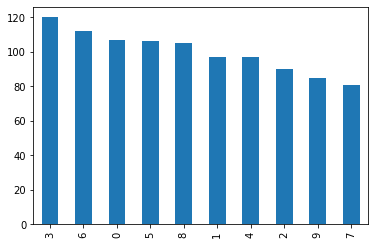

In [15]:
#Plotting the bar chart for field: Previous_Transactions
financial_data['Previous_Transactions'].value_counts().plot(kind='bar')

In [16]:
financial_data['Previous_Transactions'].value_counts(normalize=True)

3    0.120
6    0.112
0    0.107
5    0.106
8    0.105
1    0.097
4    0.097
2    0.090
9    0.085
7    0.081
Name: Previous_Transactions, dtype: float64

The difference between percentage of records for Previous_Transactions is very small. 
Lowest is 8.1% and Highest is 12%.

<Axes: >

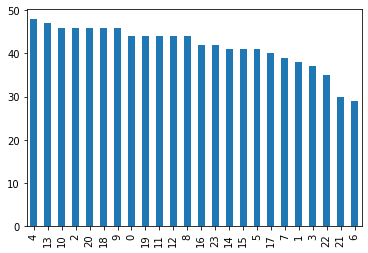

In [17]:
#Plotting the histogram for field: Time_of_Day
#plt.hist(financial_data['Time_of_Day'])
financial_data['Time_of_Day'].value_counts().plot(kind='bar')

In [18]:
financial_data['Time_of_Day'].value_counts(normalize=True)

4     0.048
13    0.047
10    0.046
2     0.046
20    0.046
18    0.046
9     0.046
0     0.044
19    0.044
11    0.044
12    0.044
8     0.044
16    0.042
23    0.042
14    0.041
15    0.041
5     0.041
17    0.040
7     0.039
1     0.038
3     0.037
22    0.035
21    0.030
6     0.029
Name: Time_of_Day, dtype: float64

The difference between percentage of records for Time_of_Day is very small. Lowest is 2.9% and Highest is 4.8%

(array([100., 106.,  88., 119.,  78., 116.,  96., 110.,  82., 105.]),
 array([20. , 25.9, 31.8, 37.7, 43.6, 49.5, 55.4, 61.3, 67.2, 73.1, 79. ]),
 <BarContainer object of 10 artists>)

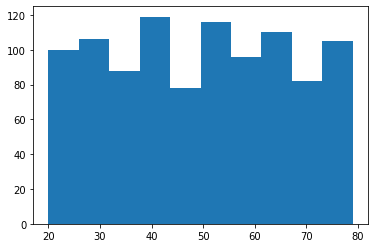

In [19]:
#Plotting the histogram for field: Customer_Age
plt.hist(financial_data['Customer_Age'])

(array([106.,  99., 102., 100., 104.,  83.,  87.,  98., 117., 104.]),
 array([-4.99891492e-01, -3.99908025e-01, -2.99924559e-01, -1.99941092e-01,
        -9.99576258e-02,  2.58406644e-05,  1.00009307e-01,  1.99992774e-01,
         2.99976240e-01,  3.99959707e-01,  4.99943173e-01]),
 <BarContainer object of 10 artists>)

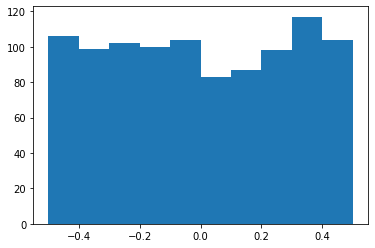

In [20]:
#Plotting the histogram for field: Velocity
plt.hist(financial_data['Velocity'])

(array([101., 110., 108., 108.,  96.,  96., 106., 100.,  83.,  92.]),
 array([ 20084.71540333,  33065.82162541,  46046.92784749,  59028.03406957,
         72009.14029166,  84990.24651374,  97971.35273582, 110952.4589579 ,
        123933.56517998, 136914.67140206, 149895.77762414]),
 <BarContainer object of 10 artists>)

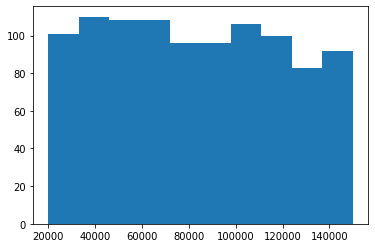

In [21]:
#Plotting the histogram for field: Customer_Income
plt.hist(financial_data['Customer_Income'])

<Axes: >

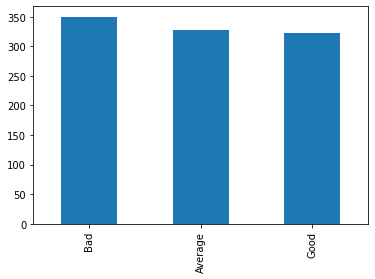

In [22]:
#Plotting the bar chart for field: Merchant_Reputation
financial_data['Merchant_Reputation'].value_counts().plot(kind='bar')

In [23]:
financial_data['Merchant_Reputation'].value_counts(normalize=True)

Bad        0.350
Average    0.327
Good       0.323
Name: Merchant_Reputation, dtype: float64

Each category in Merchant_Reputation is equally distributed.

<Axes: >

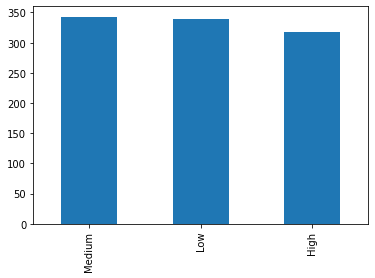

In [24]:
#Plotting the bar chart for field: Online_Transactions_Frequency
financial_data['Online_Transactions_Frequency'].value_counts().plot(kind='bar')

In [25]:
financial_data['Online_Transactions_Frequency'].value_counts(normalize=True)

Medium    0.343
Low       0.339
High      0.318
Name: Online_Transactions_Frequency, dtype: float64

Each category in Online_Transactions_Frequency is almost equally distributed around 1/3rd.

<Axes: >

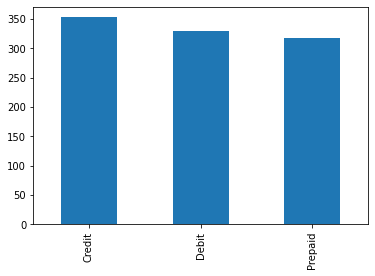

In [26]:
#Plotting the bar chart for field: Card_Type
financial_data['Card_Type'].value_counts().plot(kind='bar')

In [27]:
financial_data['Card_Type'].value_counts(normalize=True)

Credit     0.353
Debit      0.329
Prepaid    0.318
Name: Card_Type, dtype: float64

Each category in Card_Type is almost equally distributed around 1/3rd.

<Axes: >

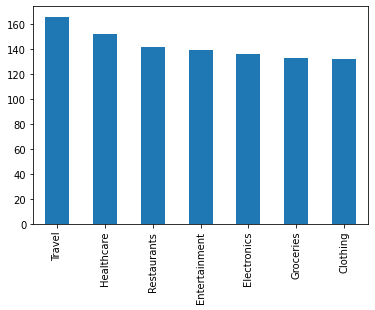

In [28]:
#Plotting the bar chart for field: MCC_Category
financial_data['MCC_Category'].value_counts().plot(kind='bar')

In [29]:
financial_data['MCC_Category'].value_counts(normalize=True)

Travel           0.166
Healthcare       0.152
Restaurants      0.142
Entertainment    0.139
Electronics      0.136
Groceries        0.133
Clothing         0.132
Name: MCC_Category, dtype: float64

The difference in percentage of records across different values of MCC_Category is very small.
Lowest is 13.2% and Highest is 16.6%

<Axes: >

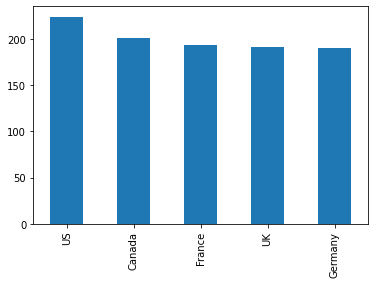

In [30]:
#Plotting the bar chart for field: Location
financial_data['Location'].value_counts().plot(kind='bar')

In [31]:
financial_data['Location'].value_counts(normalize=True)

US         0.224
Canada     0.201
France     0.194
UK         0.191
Germany    0.190
Name: Location, dtype: float64

Each category in Location is almost equally distributed around 20%

<Axes: >

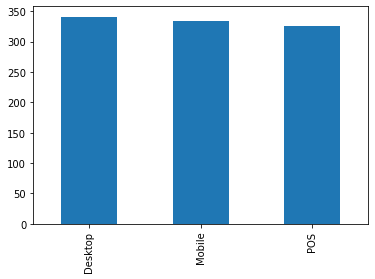

In [32]:
#Plotting the bar chart for field: Device
financial_data['Device'].value_counts().plot(kind='bar')

In [33]:
financial_data['Device'].value_counts(normalize=True)

Desktop    0.341
Mobile     0.334
POS        0.325
Name: Device, dtype: float64

Each category in Device is almost equally distributed around 1/3rd.

In [34]:
#Calculating the average amount
np.mean(financial_data['Amount'])

520.177430970136

In [35]:
#Calculating the median amount
np.median(financial_data['Amount'])

546.816714015564

There is a very small difference between mean and median amount.

(array([ 93.,  90.,  87., 105.,  86., 101., 127., 105., 110.,  96.]),
 array([ 10.45699098, 109.08028121, 207.70357144, 306.32686167,
        404.9501519 , 503.57344213, 602.19673236, 700.82002259,
        799.44331282, 898.06660306, 996.68989329]),
 <BarContainer object of 10 artists>)

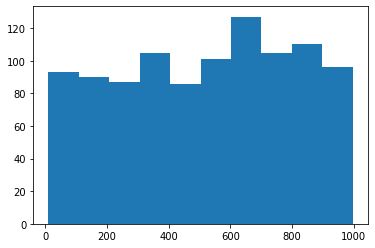

In [36]:
#Plotting the histogram for field: Amount
plt.hist(financial_data['Amount'])

We do not find any standard pattern in distibution of amount like Bell shaped curve or any other pattern.

In [37]:
#Calculating the range of Amount
amount_max=np.max(financial_data['Amount'])
amount_min=np.min(financial_data['Amount'])
amount_range=amount_max-amount_min
print("Minimum value of the amount: ",amount_min)
print("Maximum value of the amount: ",amount_max)
print("Range of the amount: ",amount_range)

Minimum value of the amount:  10.456990977145551
Maximum value of the amount:  996.6898932861582
Range of the amount:  986.2329023090126


In [38]:
#Calculating the quartile values of Amount.
amount_25=np.quantile(financial_data['Amount'],0.25)
amount_50=np.quantile(financial_data['Amount'],0.50)
amount_75=np.quantile(financial_data['Amount'],0.75)
print("25th quartile of Amount: ",amount_25)
print("50th quartile of Amount: ",amount_50)
print("75th quartile of Amount: ",amount_75)

25th quartile of Amount:  277.9785468867406
50th quartile of Amount:  546.816714015564
75th quartile of Amount:  760.0745710551089


In [39]:
#Calculating the interquartile range of Amount
print(amount_75-amount_25)

482.0960241683683


Thus, we observed the median value of Amount is more closer to 3rd quartile than 1st quartile.

In [40]:
#Calculating the range of Previous_Transactions
previousTransactions_max=np.max(financial_data['Previous_Transactions'])
previousTransactions_min=np.min(financial_data['Previous_Transactions'])
previousTransactions_range=previousTransactions_max-previousTransactions_min
print("Minimum value of the Previous_Transactions: ",previousTransactions_min)
print("Maximum value of the Previous_Transactions: ",previousTransactions_max)
print("Range of the Previous_Transactions: ",previousTransactions_range)

#Calculating the quartile values of Previous_Transactions.
previousTransactions_25=np.quantile(financial_data['Previous_Transactions'],0.25)
previousTransactions_50=np.quantile(financial_data['Previous_Transactions'],0.50)
previousTransactions_75=np.quantile(financial_data['Previous_Transactions'],0.75)
print("25th quartile of Previous_Transactions: ",previousTransactions_25)
print("50th quartile of Previous_Transactions: ",previousTransactions_50)
print("75th quartile of Previous_Transactions: ",previousTransactions_75)

#Calculating the interquartile range of Previous_Transactions
print(previousTransactions_75-previousTransactions_25)

Minimum value of the Previous_Transactions:  0
Maximum value of the Previous_Transactions:  9
Range of the Previous_Transactions:  9
25th quartile of Previous_Transactions:  2.0
50th quartile of Previous_Transactions:  4.0
75th quartile of Previous_Transactions:  7.0
5.0


Thus, we observed median value of Previous_Transactions is almost equi-distant from 25th and 75th quartile.

Minimum value of the Balance_Before_Transaction:  123.46087678511972
Maximum value of the Balance_Before_Transaction:  9975.85915441606
Range of the Balance_Before_Transaction:  9852.39827763094
25th quartile of Balance_Before_Transaction:  2435.1296805423817
50th quartile of Balance_Before_Transaction:  4794.595477210722
75th quartile of Balance_Before_Transaction:  7384.9656017981315
4949.83592125575


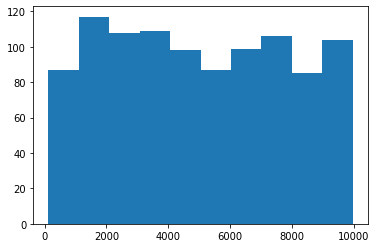

In [41]:
#Plotting the histogram for field: Balance_Before_Transaction
plt.hist(financial_data['Balance_Before_Transaction'])

#Calculating the range of Balance_Before_Transaction
Balance_Before_Transaction_max=np.max(financial_data['Balance_Before_Transaction'])
Balance_Before_Transaction_min=np.min(financial_data['Balance_Before_Transaction'])
Balance_Before_Transaction_range=Balance_Before_Transaction_max-Balance_Before_Transaction_min
print("Minimum value of the Balance_Before_Transaction: ",Balance_Before_Transaction_min)
print("Maximum value of the Balance_Before_Transaction: ",Balance_Before_Transaction_max)
print("Range of the Balance_Before_Transaction: ",Balance_Before_Transaction_range)

#Calculating the quartile values of Balance_Before_Transaction.
Balance_Before_Transaction_25=np.quantile(financial_data['Balance_Before_Transaction'],0.25)
Balance_Before_Transaction_50=np.quantile(financial_data['Balance_Before_Transaction'],0.50)
Balance_Before_Transaction_75=np.quantile(financial_data['Balance_Before_Transaction'],0.75)
print("25th quartile of Balance_Before_Transaction: ",Balance_Before_Transaction_25)
print("50th quartile of Balance_Before_Transaction: ",Balance_Before_Transaction_50)
print("75th quartile of Balance_Before_Transaction: ",Balance_Before_Transaction_75)

#Calculating the interquartile range of Previous_Transactions
print(Balance_Before_Transaction_75-Balance_Before_Transaction_25)

Thus, we observed median value of Balance_Before_Transaction is almost equi-distant from 25th and 75th quartile.

In [42]:
#Calculating the range of Customer_Age
Customer_Age_max=np.max(financial_data['Customer_Age'])
Customer_Age_min=np.min(financial_data['Customer_Age'])
Customer_Age_range=Customer_Age_max-Customer_Age_min
print("Minimum value of the Customer_Age: ",Customer_Age_min)
print("Maximum value of the Customer_Age: ",Customer_Age_max)
print("Range of the Customer_Age: ",Customer_Age_range)

#Calculating the quartile values of Customer_Age.
Customer_Age_25=np.quantile(financial_data['Customer_Age'],0.25)
Customer_Age_50=np.quantile(financial_data['Customer_Age'],0.50)
Customer_Age_75=np.quantile(financial_data['Customer_Age'],0.75)
print("25th quartile of Customer_Age: ",Customer_Age_25)
print("50th quartile of Customer_Age: ",Customer_Age_50)
print("75th quartile of Customer_Age: ",Customer_Age_75)

#Calculating the interquartile range of Customer_Age
print(Customer_Age_75-Customer_Age_25)

Minimum value of the Customer_Age:  20
Maximum value of the Customer_Age:  79
Range of the Customer_Age:  59
25th quartile of Customer_Age:  35.0
50th quartile of Customer_Age:  50.0
75th quartile of Customer_Age:  64.0
29.0


Thus, we observed median value of Customer_Age is almost equi-distant from 25th and 75th quartile.

In [43]:
#Calculating the range of Customer_Income
Customer_Income_max=np.max(financial_data['Customer_Income'])
Customer_Income_min=np.min(financial_data['Customer_Income'])
Customer_Income_range=Customer_Income_max-Customer_Income_min
print("Minimum value of the Customer_Income: ",Customer_Income_min)
print("Maximum value of the Customer_Income: ",Customer_Income_max)
print("Range of the Customer_Income: ",Customer_Income_range)

#Calculating the quartile values of Customer_Income.
Customer_Income_25=np.quantile(financial_data['Customer_Income'],0.25)
Customer_Income_50=np.quantile(financial_data['Customer_Income'],0.50)
Customer_Income_75=np.quantile(financial_data['Customer_Income'],0.75)
print("25th quartile of Customer_Income: ",Customer_Income_25)
print("50th quartile of Customer_Income: ",Customer_Income_50)
print("75th quartile of Customer_Income: ",Customer_Income_75)

#Calculating the interquartile range of Customer_Income
print(Customer_Income_75-Customer_Income_25)

Minimum value of the Customer_Income:  20084.71540332981
Maximum value of the Customer_Income:  149895.77762414375
Range of the Customer_Income:  129811.06222081394
25th quartile of Customer_Income:  51725.43492902497
50th quartile of Customer_Income:  81693.95241632251
75th quartile of Customer_Income:  113430.36354389018
61704.92861486522


Thus, we observed median value of Customer_Income is almost equi-distant from 25th and 75th quartile.

Minimum value of the Card_Limit:  526.9109117307208
Maximum value of the Card_Limit:  19978.43966842985
Range of the Card_Limit:  19451.528756699132
25th quartile of Card_Limit:  5287.512915498323
50th quartile of Card_Limit:  10569.195492571776
75th quartile of Card_Limit:  15474.888340665038
10187.375425166716


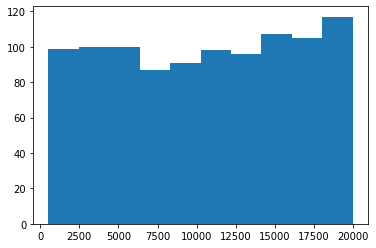

In [44]:
#Plotting the histogram for field: Card_Limit
plt.hist(financial_data['Card_Limit'])

#Calculating the range of Card_Limit
Card_Limit_max=np.max(financial_data['Card_Limit'])
Card_Limit_min=np.min(financial_data['Card_Limit'])
Card_Limit_range=Card_Limit_max-Card_Limit_min
print("Minimum value of the Card_Limit: ",Card_Limit_min)
print("Maximum value of the Card_Limit: ",Card_Limit_max)
print("Range of the Card_Limit: ",Card_Limit_range)

#Calculating the quartile values of Card_Limit.
Card_Limit_25=np.quantile(financial_data['Card_Limit'],0.25)
Card_Limit_50=np.quantile(financial_data['Card_Limit'],0.50)
Card_Limit_75=np.quantile(financial_data['Card_Limit'],0.75)
print("25th quartile of Card_Limit: ",Card_Limit_25)
print("50th quartile of Card_Limit: ",Card_Limit_50)
print("75th quartile of Card_Limit: ",Card_Limit_75)

#Calculating the interquartile range of Card_Limit
print(Card_Limit_75-Card_Limit_25)

Thus, we observed median value of Card_Limit is relatively closer to 75th quartile compared to 25th quartile.

Minimum value of the Credit_Score:  300
Maximum value of the Credit_Score:  849
Range of the Credit_Score:  549
25th quartile of Credit_Score:  441.5
50th quartile of Credit_Score:  574.5
75th quartile of Credit_Score:  715.5
274.0


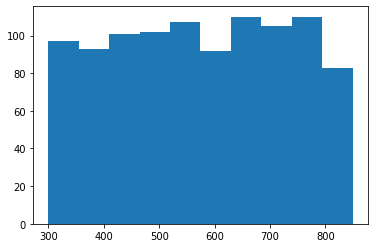

In [45]:
#Plotting the histogram for field: Credit_Score
plt.hist(financial_data['Credit_Score'])

#Calculating the range of Credit_Score
Credit_Score_max=np.max(financial_data['Credit_Score'])
Credit_Score_min=np.min(financial_data['Credit_Score'])
Credit_Score_range=Credit_Score_max-Credit_Score_min
print("Minimum value of the Credit_Score: ",Credit_Score_min)
print("Maximum value of the Credit_Score: ",Credit_Score_max)
print("Range of the Credit_Score: ",Credit_Score_range)

#Calculating the quartile values of Credit_Score.
Credit_Score_25=np.quantile(financial_data['Credit_Score'],0.25)
Credit_Score_50=np.quantile(financial_data['Credit_Score'],0.50)
Credit_Score_75=np.quantile(financial_data['Credit_Score'],0.75)
print("25th quartile of Credit_Score: ",Credit_Score_25)
print("50th quartile of Credit_Score: ",Credit_Score_50)
print("75th quartile of Credit_Score: ",Credit_Score_75)

#Calculating the interquartile range of Credit_Score
print(Credit_Score_75-Credit_Score_25)

Thus, we observed median value of Credit_Score is relatively closer to 25th quartile compared to 75th quartile.

Minimum value of the Spending_Patterns:  500.5590900733376
Maximum value of the Spending_Patterns:  4994.352225083275
Range of the Spending_Patterns:  4493.793135009937
25th quartile of Spending_Patterns:  1561.5768684131933
50th quartile of Spending_Patterns:  2839.222191291903
75th quartile of Spending_Patterns:  3860.4827752396664
2298.9059068264733


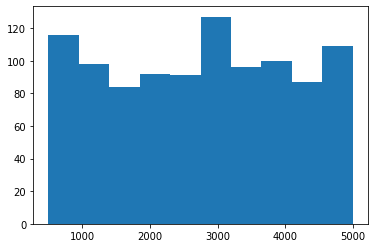

In [46]:
#Plotting the histogram for field: Spending_Patterns
plt.hist(financial_data['Spending_Patterns'])

#Calculating the range of Spending_Patterns
Spending_Patterns_max=np.max(financial_data['Spending_Patterns'])
Spending_Patterns_min=np.min(financial_data['Spending_Patterns'])
Spending_Patterns_range=Spending_Patterns_max-Spending_Patterns_min
print("Minimum value of the Spending_Patterns: ",Spending_Patterns_min)
print("Maximum value of the Spending_Patterns: ",Spending_Patterns_max)
print("Range of the Spending_Patterns: ",Spending_Patterns_range)

#Calculating the quartile values of Spending_Patterns.
Spending_Patterns_25=np.quantile(financial_data['Spending_Patterns'],0.25)
Spending_Patterns_50=np.quantile(financial_data['Spending_Patterns'],0.50)
Spending_Patterns_75=np.quantile(financial_data['Spending_Patterns'],0.75)
print("25th quartile of Spending_Patterns: ",Spending_Patterns_25)
print("50th quartile of Spending_Patterns: ",Spending_Patterns_50)
print("75th quartile of Spending_Patterns: ",Spending_Patterns_75)

#Calculating the interquartile range of Spending_Patterns
print(Spending_Patterns_75-Spending_Patterns_25)

Thus, we observed median value of Spending_Patterns is relatively closer to 75th quartile compared to 25th quartile.

Minimum value of the Merchant_Location_History:  1
Maximum value of the Merchant_Location_History:  19
Range of the Merchant_Location_History:  18
25th quartile of Merchant_Location_History:  5.0
50th quartile of Merchant_Location_History:  10.0
75th quartile of Merchant_Location_History:  14.0
9.0


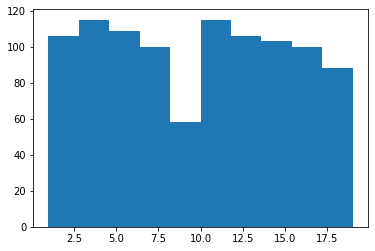

In [47]:
#Plotting the histogram for field: Merchant_Location_History
plt.hist(financial_data['Merchant_Location_History'])

#Calculating the range of Merchant_Location_History
Merchant_Location_History_max=np.max(financial_data['Merchant_Location_History'])
Merchant_Location_History_min=np.min(financial_data['Merchant_Location_History'])
Merchant_Location_History_range=Merchant_Location_History_max-Merchant_Location_History_min
print("Minimum value of the Merchant_Location_History: ",Merchant_Location_History_min)
print("Maximum value of the Merchant_Location_History: ",Merchant_Location_History_max)
print("Range of the Merchant_Location_History: ",Merchant_Location_History_range)

#Calculating the quartile values of Merchant_Location_History.
Merchant_Location_History_25=np.quantile(financial_data['Merchant_Location_History'],0.25)
Merchant_Location_History_50=np.quantile(financial_data['Merchant_Location_History'],0.50)
Merchant_Location_History_75=np.quantile(financial_data['Merchant_Location_History'],0.75)
print("25th quartile of Merchant_Location_History: ",Merchant_Location_History_25)
print("50th quartile of Merchant_Location_History: ",Merchant_Location_History_50)
print("75th quartile of Merchant_Location_History: ",Merchant_Location_History_75)

#Calculating the interquartile range of Merchant_Location_History
print(Merchant_Location_History_75-Merchant_Location_History_25)

# Bi-variate analysis

In [48]:
#Creating a new datframe to store target variable as Categorical
financial_data_target_categorical=financial_data.copy(deep=True)

In [49]:
financial_data_target_categorical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Amount                         1000 non-null   float64
 1   Date                           1000 non-null   object 
 2   Card_Type                      1000 non-null   object 
 3   MCC_Category                   1000 non-null   object 
 4   Location                       1000 non-null   object 
 5   Device                         1000 non-null   object 
 6   Previous_Transactions          1000 non-null   int64  
 7   Balance_Before_Transaction     1000 non-null   float64
 8   Time_of_Day                    1000 non-null   int64  
 9   Velocity                       1000 non-null   float64
 10  Customer_Age                   1000 non-null   int64  
 11  Customer_Income                1000 non-null   float64
 12  Card_Limit                     1000 non-null   fl

In [50]:
#Adding a new column: Fraudulent
financial_data_target_categorical.insert(18,"Fraudulent","")
financial_data_target_categorical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Amount                         1000 non-null   float64
 1   Date                           1000 non-null   object 
 2   Card_Type                      1000 non-null   object 
 3   MCC_Category                   1000 non-null   object 
 4   Location                       1000 non-null   object 
 5   Device                         1000 non-null   object 
 6   Previous_Transactions          1000 non-null   int64  
 7   Balance_Before_Transaction     1000 non-null   float64
 8   Time_of_Day                    1000 non-null   int64  
 9   Velocity                       1000 non-null   float64
 10  Customer_Age                   1000 non-null   int64  
 11  Customer_Income                1000 non-null   float64
 12  Card_Limit                     1000 non-null   fl

In [51]:
i=0
while(i<len(financial_data_target_categorical['Is_Fraudulent'])):
    if(financial_data_target_categorical['Is_Fraudulent'][i]==0):
        financial_data_target_categorical['Fraudulent'][i]='No'
    elif(financial_data_target_categorical['Is_Fraudulent'][i]==1):
        financial_data_target_categorical['Fraudulent'][i]='Yes'
    i=i+1

<ipython-input-51-7a83e5b25707>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financial_data_target_categorical['Fraudulent'][i]='No'
<ipython-input-51-7a83e5b25707>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financial_data_target_categorical['Fraudulent'][i]='Yes'


In [52]:
financial_data_target_categorical.head(5)

,Amount,Date,Card_Type,MCC_Category,Location,Device,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Reputation,Merchant_Location_History,Spending_Patterns,Online_Transactions_Frequency,Fraudulent,Is_Fraudulent
0,180.924993,2023-07-02,Debit,Electronics,UK,Desktop,6,919.055267,10,-0.337955,52,105545.340543,2503.758986,401,Average,6,828.820298,Medium,No,0
1,794.625797,2023-02-18,Prepaid,Groceries,Canada,Desktop,5,3529.930762,17,0.015117,62,92651.854405,12885.681726,409,Average,13,4384.528307,Low,Yes,1
2,818.413303,2023-01-02,Prepaid,Electronics,UK,POS,5,6578.889931,4,-0.198457,42,90579.479280,2039.105869,323,Good,1,733.282224,High,No,0
3,530.306522,2023-03-21,Credit,Restaurants,US,Mobile,3,8036.856328,20,-0.076741,76,63777.184316,5568.880208,674,Bad,1,670.074148,High,No,0
4,649.101853,2023-08-28,Debit,Electronics,Canada,Desktop,4,5342.795887,16,-0.029077,39,30620.998085,6945.439545,533,Good,3,550.619875,Low,No,0


In [53]:
financial_data_target_categorical.tail(5)

,Amount,Date,Card_Type,MCC_Category,Location,Device,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Reputation,Merchant_Location_History,Spending_Patterns,Online_Transactions_Frequency,Fraudulent,Is_Fraudulent
995,536.205566,2023-05-21,Debit,Healthcare,Germany,Mobile,6,7131.892816,0,0.428024,72,54013.284619,11581.476660,656,Average,14,1689.854359,High,No,0
996,615.954996,2023-04-16,Credit,Clothing,Germany,Desktop,8,6940.176274,14,0.430410,40,140803.006752,15882.824558,312,Bad,11,856.937352,High,No,0
997,472.562610,2023-08-27,Credit,Healthcare,France,Desktop,4,4209.798746,9,0.477102,54,52788.254160,17589.131736,424,Average,4,2356.880557,Low,No,0
998,517.723900,2023-11-25,Debit,Entertainment,US,POS,8,496.330227,4,0.331765,21,65820.723836,15900.001061,529,Good,6,814.016929,Low,No,0
999,489.865943,2023-11-09,Debit,Electronics,US,Desktop,0,4015.643994,13,0.109080,71,127303.531382,14111.272226,542,Average,7,1311.880140,Medium,No,0


In [54]:
#Dropping the column: Is_Fraudulent from financial_data_target_categorical
financial_data_target_categorical.drop(['Is_Fraudulent'],axis=1,inplace=True)

In [55]:
financial_data_target_categorical.head()

,Amount,Date,Card_Type,MCC_Category,Location,Device,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Reputation,Merchant_Location_History,Spending_Patterns,Online_Transactions_Frequency,Fraudulent
0,180.924993,2023-07-02,Debit,Electronics,UK,Desktop,6,919.055267,10,-0.337955,52,105545.340543,2503.758986,401,Average,6,828.820298,Medium,No
1,794.625797,2023-02-18,Prepaid,Groceries,Canada,Desktop,5,3529.930762,17,0.015117,62,92651.854405,12885.681726,409,Average,13,4384.528307,Low,Yes
2,818.413303,2023-01-02,Prepaid,Electronics,UK,POS,5,6578.889931,4,-0.198457,42,90579.479280,2039.105869,323,Good,1,733.282224,High,No
3,530.306522,2023-03-21,Credit,Restaurants,US,Mobile,3,8036.856328,20,-0.076741,76,63777.184316,5568.880208,674,Bad,1,670.074148,High,No
4,649.101853,2023-08-28,Debit,Electronics,Canada,Desktop,4,5342.795887,16,-0.029077,39,30620.998085,6945.439545,533,Good,3,550.619875,Low,No


In [56]:
#Card_Type vs Fraudulent
pd.crosstab(financial_data_target_categorical['Card_Type'],financial_data_target_categorical['Fraudulent'],margins=True)

Fraudulent,No,Yes,All
Card_Type,,,
Credit,332,21,353
Debit,312,17,329
Prepaid,303,15,318
All,947,53,1000


Out of all 53 fraudulent transactions: -

1. 21 have Card_Type=Credit  -> 40% of the fraudulent transactions
2. 17 have Card_Type=Debit   -> 32% of the fraudulent transactions
3. 15 have Card_Type=Prepaid -> 28% of the fraudulent transactions

Out of 353 transactions with Card_Type=Credit: -

21 are fraudulent. -> 5.94%

Out of 329 transactions with Card_Type=Debit: -

17 are fraudulent. -> 5.16%

Out of 318 transactions with Card_Type=Prepaid: -

15 are fraudulent. -> 4.71%

In [57]:
#MCC_Category vs Fraudulent
pd.crosstab(financial_data_target_categorical['MCC_Category'],financial_data_target_categorical['Fraudulent'],margins=True)

Fraudulent,No,Yes,All
MCC_Category,,,
Clothing,129,3,132
Electronics,128,8,136
Entertainment,132,7,139
Groceries,125,8,133
Healthcare,139,13,152
Restaurants,135,7,142
Travel,159,7,166
All,947,53,1000


Out of all 53 fraudulent transactions: -
1. 3 have MCC_Category=Clothing.       -> 5.66% of the fraudulent transactions
2. 8 have MCC_Category=Electronics.    -> 15.09% of the fraudulent transactions
3. 7 have MCC_Category=Entertainment.  -> 13.20% of the fraudulent transactions
4. 8 have MCC_Category=Groceries.      -> 15.09% of the fraudulent transactions
5. 13 have MCC_Category=Healthcare.    -> 24.52% of the fraudulent transactions
6. 7 have MCC_Category=Restaurants.    -> 13.20% of the fraudulent transactions
7. 7 have MCC_Category=Travel.         -> 13.20% of the fraudulent transactions

Out of 132 transactions with MCC_Category=Clothing: -
3 are fraudulent. -> 2.27%

Out of 136 transactions with MCC_Category=Electronics: -
8 are fraudulent. -> 5.88%

Out of 139 transactions with MCC_Category=Entertainment: -
7 are fraudulent -> 5.03%

Out of 133 transactions with MCC_Category=Groceries: -
8 are fraudulent. -> 6.01%

Out of 152 transactions with MCC_Category=Healtcare: -
13 are fraudulent. -> 8.55%

Out of 142 transactions with MCC_Category=Restaurants: -
7 are fraudulent. -> 4.92%

Out of 166 transactions with MCC_Category=Travel: -
6 are fraudulent. -> 3.61%

In [58]:
#Location vs Fraudulent
pd.crosstab(financial_data_target_categorical['Location'],financial_data_target_categorical['Fraudulent'],margins=True)

Fraudulent,No,Yes,All
Location,,,
Canada,188,13,201
France,178,16,194
Germany,186,4,190
UK,184,7,191
US,211,13,224
All,947,53,1000


Out of 53 fraudulent transactions: -
1. 13 have Location=Canada  -> 24.52%
2. 16 have Location=France  -> 30%
3. 4 have Location=Germany  -> 7.54%
4. 7 have Location=UK       -> 13.20%
5. 13 have Location=US      -> 24.52%

Out of 201 transactions with Location=Canada: - 13 are fraudulent. -> 6.46%

Out of 194 transactions with Location=France: - 16 are fraudulent. -> 8.24%

Out of 190 transactions with Location=Germany: - 4 are fraudulent. -> 2.10%

Out of 191 transactions with Location=UK: - 7 are fraudulent.      -> 3.66%

Out of 224 transactions with Location=US: - 13 are fraudulent.     -> 5.80%

In [59]:
#Device vs Fraudulent
pd.crosstab(financial_data_target_categorical['Device'],financial_data_target_categorical['Fraudulent'],margins=True)

Fraudulent,No,Yes,All
Device,,,
Desktop,321,20,341
Mobile,317,17,334
POS,309,16,325
All,947,53,1000


Out of 53 fraudulent transactions: -

1. 20 have Device=Desktop -> 37.73%
2. 17 have Device=Mobile  -> 32.07%
3. 16 have Device=POS     -> 30.18%

Out of 341 transactions with Device=Desktop: - 20 are fraudulent. -> 5.86%

Out of 334 transactions with Device=Mobile: - 17 are fraudulent.  -> 5.08%

Out of 325 transactions with Device=POS: - 16 are fraudulent.     -> 4.92%

In [60]:
#Merchant_Reputation vs Fraudulent
pd.crosstab(financial_data_target_categorical['Merchant_Reputation'],financial_data_target_categorical['Fraudulent'],margins=True)

Fraudulent,No,Yes,All
Merchant_Reputation,,,
Average,307,20,327
Bad,335,15,350
Good,305,18,323
All,947,53,1000


Out of 53 fraudulent transactions: -

1. 20 have Merchant_Reputation=Average -> 37.73%
2. 15 have Merchant_Reputation=Bad     -> 28.30%
3. 18 have Merchant_Reputation=Good    -> 33.96%

Out of 327 transactions with Merchant_Reputation=Average: - 20 are fraudulent. -> 6.11%

Out of 350 transactions with Merchant_Reputation=Bad: - 15 are fraudulent.     -> 4.28%

Out of 323 transactions with Merchant_Reputation=Good: - 18 are fraudulent.    -> 5.57%

In [61]:
#Online_Transactions_Frequency vs Fraudulent
pd.crosstab(financial_data_target_categorical['Online_Transactions_Frequency'],financial_data_target_categorical['Fraudulent'],margins=True)

Fraudulent,No,Yes,All
Online_Transactions_Frequency,,,
High,299,19,318
Low,323,16,339
Medium,325,18,343
All,947,53,1000


Out of 53 fraudulent transactions: -
1. 19 have Online_Transaction_Frequency=High.   -> 35.84%
2. 16 have Online Transaction_Frequency=Low.    -> 30.18%
3. 18 have Online_Transaction_Frequency=Medium. -> 33.96%

Out of 318 transactions with Online_Transaction_Frequency=High: - 19 are fraudulent.   -> 5.97%

Out of 339 transactions with Online_Transaction_Frequency=Low: - 16 are fraudulent.    -> 4.71%

Out of 343 transactions with Online_Transaction_Frequency=Medium: - 18 are fraudulent. -> 5.24%

Fraudulent
No     520.283965
Yes    518.273898
Name: Amount, dtype: float64

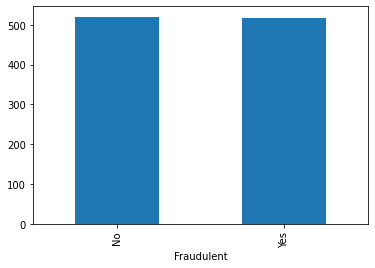

In [62]:
#Amount vs Fraudulent
financial_data_target_categorical.groupby('Fraudulent')['Amount'].mean().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Amount'].mean()

Fraudulent
No     548.606272
Yes    520.999963
Name: Amount, dtype: float64

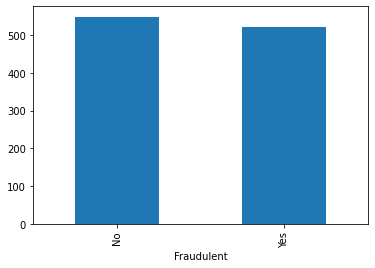

In [63]:
financial_data_target_categorical.groupby('Fraudulent')['Amount'].median().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Amount'].median()

In [64]:
print("Minimum amount: ",financial_data_target_categorical['Amount'].min())
print("Minimum amount: ",financial_data_target_categorical['Amount'].max())

Minimum amount:  10.456990977145551
Minimum amount:  996.6898932861582


<Axes: title={'center': 'Amount'}, xlabel='Fraudulent'>

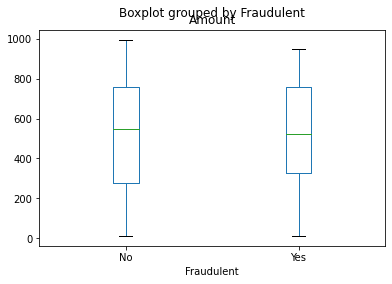

In [65]:
financial_data_target_categorical.boxplot(by='Fraudulent', column=['Amount'],grid=False)

In [66]:
bins=[10,100,200,300,400,500,600,700,800,900,1000]
financial_data_target_categorical['Amount_bin']=pd.cut(financial_data_target_categorical['Amount'],bins)

In [67]:
Amount_bin=pd.crosstab(financial_data_target_categorical['Amount_bin'],financial_data_target_categorical['Fraudulent'])

Fraudulent,No,Yes
Amount_bin,,
"(10, 100]",0.962963,0.037037
"(100, 200]",0.968085,0.031915
"(200, 300]",0.943820,0.056180
"(300, 400]",0.913462,0.086538
"(400, 500]",0.933333,0.066667
"(500, 600]",0.961165,0.038835
"(600, 700]",0.953125,0.046875
"(700, 800]",0.915888,0.084112
"(800, 900]",0.962963,0.037037


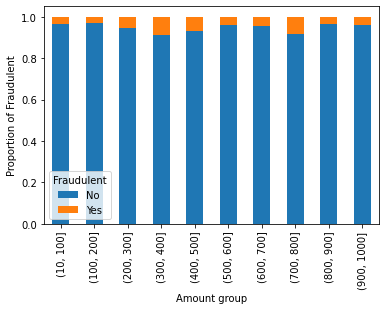

In [68]:
Amount_bin.div(Amount_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Amount group")
plt.ylabel("Proportion of Fraudulent")
Amount_bin.div(Amount_bin.sum(1).astype(float),axis=0)

Fraudulent,No,Yes
Amount_bin,,
"(10, 278]",0.960000,0.040000
"(278, 547]",0.924303,0.075697
"(547, 767]",0.953125,0.046875
"(767, 998]",0.950617,0.049383


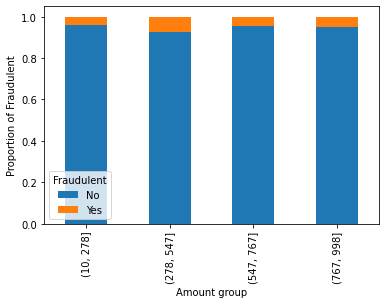

In [69]:
bins=[10,278,547,767,998]
financial_data_target_categorical['Amount_bin']=pd.cut(financial_data_target_categorical['Amount'],bins)
Amount_bin=pd.crosstab(financial_data_target_categorical['Amount_bin'],financial_data_target_categorical['Fraudulent'])
Amount_bin.div(Amount_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Amount group")
plt.ylabel("Proportion of Fraudulent")
Amount_bin.div(Amount_bin.sum(1).astype(float),axis=0)

Irrespective of the range of Amount, most of the transactions are not Fraudulent.

However, we also observed when value of Amount is between first quartile and median value, the number of fraudulen transactions are maximum as compared to other three quarterly distributions of Amount.

Fraudulent
No     4.422386
Yes    3.981132
Name: Previous_Transactions, dtype: float64

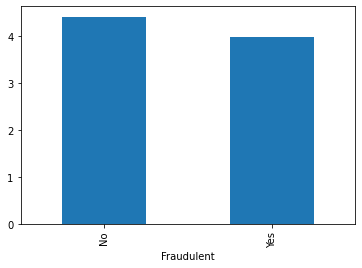

In [70]:
#Previous_Transactions vs Fraudulent
financial_data_target_categorical.groupby('Fraudulent')['Previous_Transactions'].mean().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Previous_Transactions'].mean()

Fraudulent
No     4
Yes    4
Name: Previous_Transactions, dtype: int64

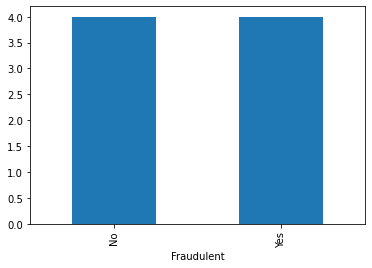

In [71]:
financial_data_target_categorical.groupby('Fraudulent')['Previous_Transactions'].median().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Previous_Transactions'].median()

In [72]:
print("Minimum Previous Transactions: ",financial_data_target_categorical['Previous_Transactions'].min())
print("Maximum Previous Transactions: ",financial_data_target_categorical['Previous_Transactions'].max())

Minimum Previous Transactions:  0
Maximum Previous Transactions:  9


Fraudulent,No,Yes
Previous_Transactions_bin,,
"(0, 1]",0.927835,0.072165
"(1, 2]",0.944444,0.055556
"(2, 3]",0.933333,0.066667
"(3, 4]",0.927835,0.072165
"(4, 5]",0.962264,0.037736
"(5, 6]",0.973214,0.026786
"(6, 7]",0.962963,0.037037
"(7, 8]",0.933333,0.066667
"(8, 9]",0.964706,0.035294


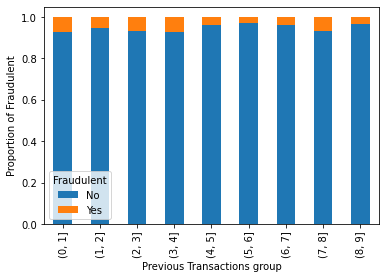

In [73]:
bins=[0,1,2,3,4,5,6,7,8,9,10]
financial_data_target_categorical['Previous_Transactions_bin']=pd.cut(financial_data_target_categorical['Previous_Transactions'],bins)
Previous_Transactions_bin=pd.crosstab(financial_data_target_categorical['Previous_Transactions_bin'],financial_data_target_categorical['Fraudulent'])
Previous_Transactions_bin.div(Previous_Transactions_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Previous Transactions group")
plt.ylabel("Proportion of Fraudulent")
Previous_Transactions_bin.div(Previous_Transactions_bin.sum(1).astype(float),axis=0)

Fraudulent,No,Yes
Previous_Transactions_bin,,
"(0, 3]",0.934853,0.065147
"(3, 5]",0.945813,0.054187
"(5, 8]",0.956376,0.043624
"(8, 10]",0.964706,0.035294


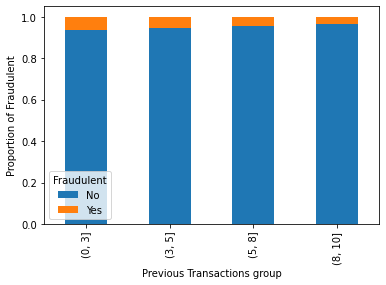

In [74]:
bins=[0,3,5,8,10]
financial_data_target_categorical['Previous_Transactions_bin']=pd.cut(financial_data_target_categorical['Previous_Transactions'],bins)
Previous_Transactions_bin=pd.crosstab(financial_data_target_categorical['Previous_Transactions_bin'],financial_data_target_categorical['Fraudulent'])
Previous_Transactions_bin.div(Previous_Transactions_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Previous Transactions group")
plt.ylabel("Proportion of Fraudulent")
Previous_Transactions_bin.div(Previous_Transactions_bin.sum(1).astype(float),axis=0)

We observed Previous Transactions is inversely related to  Fraudulent count of transactions. That is as value of Previous_Transactions increases, the number of Fraudulent transactions decreases. However, there is a small exception when Previous_Transactions=7

Fraudulent
No     4992.347027
Yes    4674.484922
Name: Balance_Before_Transaction, dtype: float64

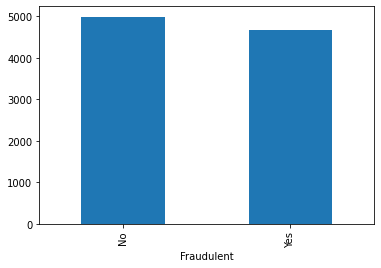

In [75]:
#Balance_Before_Transaction vs Fraudulent
financial_data_target_categorical.groupby('Fraudulent')['Balance_Before_Transaction'].mean().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Balance_Before_Transaction'].mean()

Fraudulent
No     4805.810840
Yes    4748.001645
Name: Balance_Before_Transaction, dtype: float64

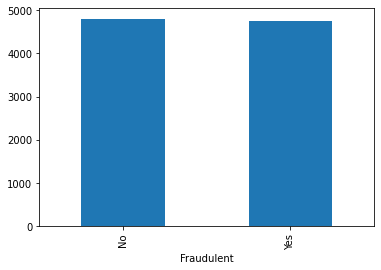

In [76]:
financial_data_target_categorical.groupby('Fraudulent')['Balance_Before_Transaction'].median().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Balance_Before_Transaction'].median()

In [77]:
print("Minimum Balance_Before_Transaction: ",financial_data_target_categorical['Balance_Before_Transaction'].min())
print("Maximum Balance_Before_Transaction: ",financial_data_target_categorical['Balance_Before_Transaction'].max())

Minimum Balance_Before_Transaction:  123.46087678511972
Maximum Balance_Before_Transaction:  9975.85915441606


Fraudulent,No,Yes
Balance_Before_Transaction_bin,,
"(100, 1000]",0.961538,0.038462
"(1000, 2000]",0.956140,0.043860
"(2000, 3000]",0.922414,0.077586
"(3000, 4000]",0.922330,0.077670
"(4000, 5000]",0.971429,0.028571
"(5000, 6000]",0.920455,0.079545
"(6000, 7000]",0.920000,0.080000
"(7000, 8000]",0.971963,0.028037
"(8000, 9000]",0.977273,0.022727


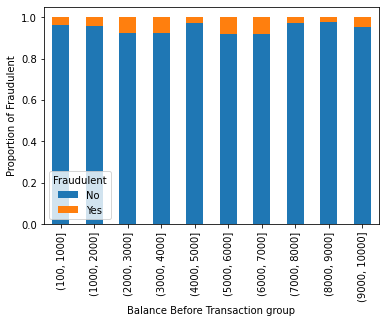

In [78]:
bins=[100,1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]
financial_data_target_categorical['Balance_Before_Transaction_bin']=pd.cut(financial_data_target_categorical['Balance_Before_Transaction'],bins)
Balance_Before_Transaction_bin=pd.crosstab(financial_data_target_categorical['Balance_Before_Transaction_bin'],financial_data_target_categorical['Fraudulent'])
Balance_Before_Transaction_bin.div(Balance_Before_Transaction_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Balance Before Transaction group")
plt.ylabel("Proportion of Fraudulent")
Balance_Before_Transaction_bin.div(Balance_Before_Transaction_bin.sum(1).astype(float),axis=0)

Fraudulent,No,Yes
Balance_Before_Transaction_bin,,
"(123, 2436]",0.944,0.056
"(2436, 4795]",0.948,0.052
"(4795, 7385]",0.928,0.072
"(7385, 9976]",0.968,0.032


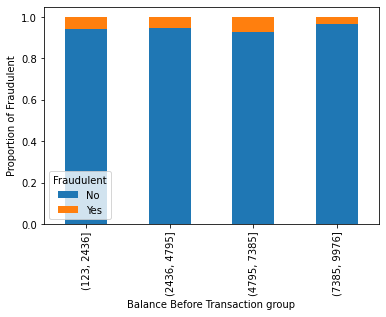

In [79]:
bins=[123,2436,4795,7385,9976]
financial_data_target_categorical['Balance_Before_Transaction_bin']=pd.cut(financial_data_target_categorical['Balance_Before_Transaction'],bins)
Balance_Before_Transaction_bin=pd.crosstab(financial_data_target_categorical['Balance_Before_Transaction_bin'],financial_data_target_categorical['Fraudulent'])
Balance_Before_Transaction_bin.div(Balance_Before_Transaction_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Balance Before Transaction group")
plt.ylabel("Proportion of Fraudulent")
Balance_Before_Transaction_bin.div(Balance_Before_Transaction_bin.sum(1).astype(float),axis=0)

We observed when Balance Before Transactions is between Median and Third quartile, the count of fraudulent transactions is maximum as compared to other three quaterly distribution of Balance Before Transactions.

Fraudulent
No     49.498416
Yes    48.245283
Name: Customer_Age, dtype: float64

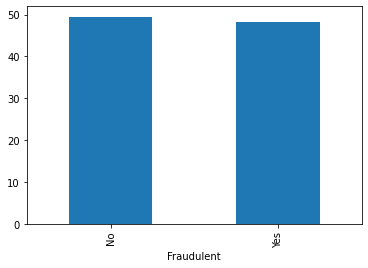

In [80]:
#Customer_Age vs Fraudulent
financial_data_target_categorical.groupby('Fraudulent')['Customer_Age'].mean().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Customer_Age'].mean()

Fraudulent
No     50
Yes    48
Name: Customer_Age, dtype: int64

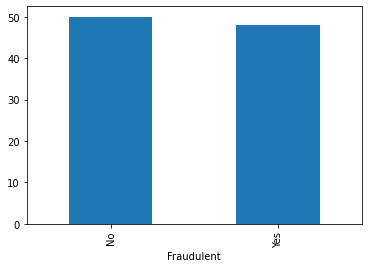

In [81]:
financial_data_target_categorical.groupby('Fraudulent')['Customer_Age'].median().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Customer_Age'].median()

Fraudulent,No,Yes
Customer_Age_bin,,
"(20, 30]",0.947368,0.052632
"(30, 40]",0.932927,0.067073
"(40, 50]",0.949686,0.050314
"(50, 60]",0.956044,0.043956
"(60, 70]",0.913043,0.086957
"(70, 80]",0.979452,0.020548


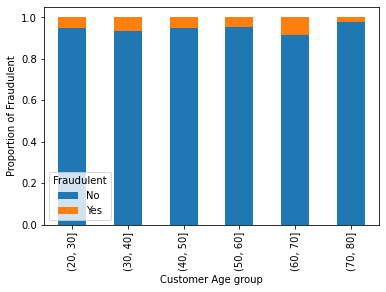

In [82]:
bins=[20,30,40,50,60,70,80]
financial_data_target_categorical['Customer_Age_bin']=pd.cut(financial_data_target_categorical['Customer_Age'],bins)
Customer_Age_bin=pd.crosstab(financial_data_target_categorical['Customer_Age_bin'],financial_data_target_categorical['Fraudulent'])
Customer_Age_bin.div(Customer_Age_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Customer Age group")
plt.ylabel("Proportion of Fraudulent")
Customer_Age_bin.div(Customer_Age_bin.sum(1).astype(float),axis=0)

Fraudulent,No,Yes
Customer_Age_bin,,
"(20, 36]",0.935849,0.064151
"(36, 51]",0.955102,0.044898
"(51, 65]",0.932000,0.068000
"(65, 80]",0.964126,0.035874


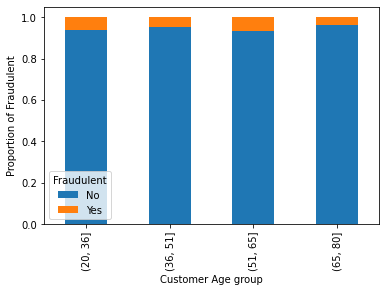

In [83]:
bins=[20,36,51,65,80]
financial_data_target_categorical['Customer_Age_bin']=pd.cut(financial_data_target_categorical['Customer_Age'],bins)
Customer_Age_bin=pd.crosstab(financial_data_target_categorical['Customer_Age_bin'],financial_data_target_categorical['Fraudulent'])
Customer_Age_bin.div(Customer_Age_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Customer Age group")
plt.ylabel("Proportion of Fraudulent")
Customer_Age_bin.div(Customer_Age_bin.sum(1).astype(float),axis=0)

We observed the count of Fraudulent transactions is relatively higher when Customer Age is in first quarter and third quarter compared to the other two quarters.

Thus, we observed for Customer Age: -
1. 20 to 35: - 6.4% of the total transactions are fraudulent. [1st quarter]
2. 51 to 64: - 6.8% of the total transactions are fraudulent. [3rd quarter]
3. 36 to 50: - 4.4% of the total transactions are fraudulent. [2nd quarter]
4. 65 to 79: - 3.5% of the total transactions are fraudulent. [4th quarter]

Fraudulent
No     82789.191132
Yes    86080.237991
Name: Customer_Income, dtype: float64

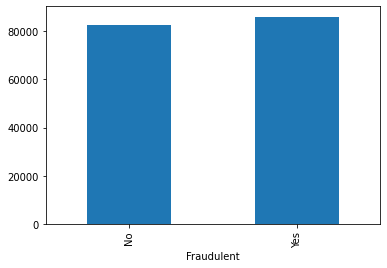

In [84]:
#Customer_Income vs Fraudulent
financial_data_target_categorical.groupby('Fraudulent')['Customer_Income'].mean().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Customer_Income'].mean()

Fraudulent
No     81489.893666
Yes    91138.030432
Name: Customer_Income, dtype: float64

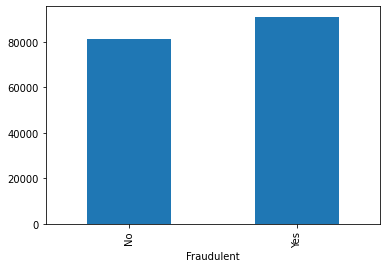

In [85]:
financial_data_target_categorical.groupby('Fraudulent')['Customer_Income'].median().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Customer_Income'].median()

Fraudulent,No,Yes
Customer_Income_bin,,
"(20084, 51726]",0.960,0.040
"(51726, 81694]",0.952,0.048
"(81694, 113431]",0.924,0.076
"(113431, 149896]",0.952,0.048


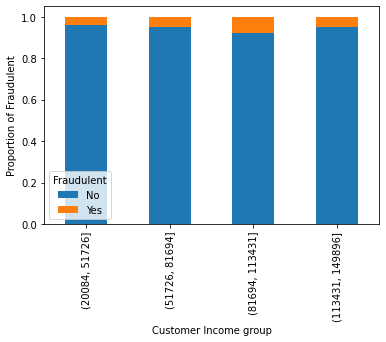

In [86]:
bins=[20084,51726,81694,113431,149896]
financial_data_target_categorical['Customer_Income_bin']=pd.cut(financial_data_target_categorical['Customer_Income'],bins)
Customer_Income_bin=pd.crosstab(financial_data_target_categorical['Customer_Income_bin'],financial_data_target_categorical['Fraudulent'])
Customer_Income_bin.div(Customer_Income_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Customer Income group")
plt.ylabel("Proportion of Fraudulent")
Customer_Income_bin.div(Customer_Income_bin.sum(1).astype(float),axis=0)

We observed maximum number of fraudulent transactions with respect to Customer_Income are in the 3rd quarter: 81694 and 113430: 7.6%.

In remaining three quarters, the fraudulent transactions are around 4.8% with respect to Customer Income.

Fraudulent
No     10442.994618
Yes    11028.135799
Name: Card_Limit, dtype: float64

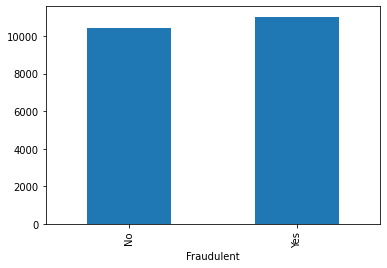

In [87]:
#Card_Limit vs Fraudulent
financial_data_target_categorical.groupby('Fraudulent')['Card_Limit'].mean().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Card_Limit'].mean()

Fraudulent
No     10513.677951
Yes    11237.203640
Name: Card_Limit, dtype: float64

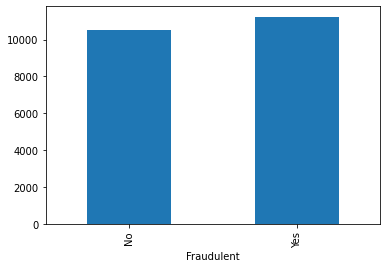

In [88]:
financial_data_target_categorical.groupby('Fraudulent')['Card_Limit'].median().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Card_Limit'].median()

Fraudulent,No,Yes
Card_Limit_bin,,
"(526, 5288]",0.952,0.048
"(5288, 10570]",0.952,0.048
"(10570, 15475]",0.956,0.044
"(15475, 19979]",0.928,0.072


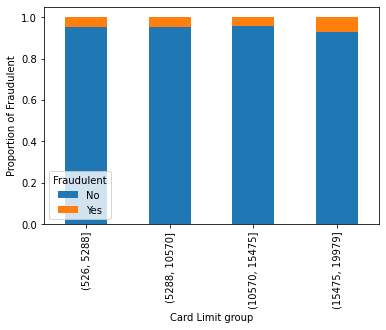

In [89]:
bins=[526,5288,10570,15475,19979]
financial_data_target_categorical['Card_Limit_bin']=pd.cut(financial_data_target_categorical['Card_Limit'],bins)
Card_Limit_bin=pd.crosstab(financial_data_target_categorical['Card_Limit_bin'],financial_data_target_categorical['Fraudulent'])
Card_Limit_bin.div(Card_Limit_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Card Limit group")
plt.ylabel("Proportion of Fraudulent")
Card_Limit_bin.div(Card_Limit_bin.sum(1).astype(float),axis=0)

We observed maximum number of fraudulent transactions with respect to Card Limit are in 4th quarter: 15475 to 19978: 7.2%

In remaining three quarters, the percenatage of fraudulent transactions with respect to Card Limit is 4.8%.

Fraudulent
No     574.421331
Yes    594.924528
Name: Credit_Score, dtype: float64

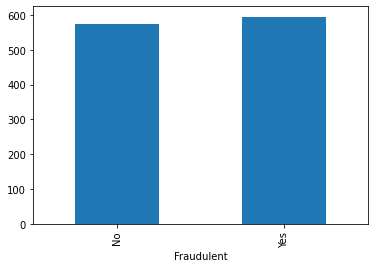

In [90]:
#Credit_Score vs Fraudulent
financial_data_target_categorical.groupby('Fraudulent')['Credit_Score'].mean().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Credit_Score'].mean()

Fraudulent
No     572
Yes    624
Name: Credit_Score, dtype: int64

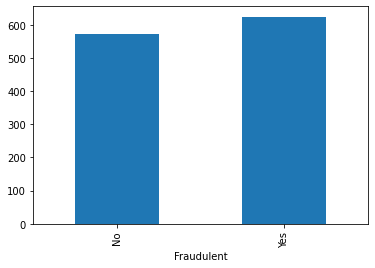

In [91]:
financial_data_target_categorical.groupby('Fraudulent')['Credit_Score'].median().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Credit_Score'].median()

Fraudulent,No,Yes
Credit_Score_bin,,
"(300, 442]",0.939024,0.060976
"(442, 575]",0.972222,0.027778
"(575, 716]",0.951417,0.048583
"(716, 850]",0.928000,0.072000


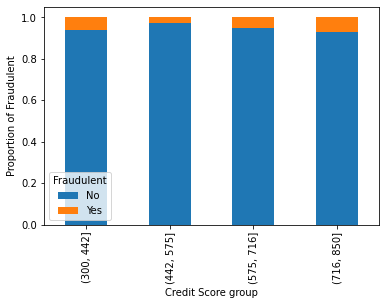

In [92]:
bins=[300,442,575,716,850]
financial_data_target_categorical['Credit_Score_bin']=pd.cut(financial_data_target_categorical['Credit_Score'],bins)
Credit_Score_bin=pd.crosstab(financial_data_target_categorical['Credit_Score_bin'],financial_data_target_categorical['Fraudulent'])
Credit_Score_bin.div(Credit_Score_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Credit Score group")
plt.ylabel("Proportion of Fraudulent")
Credit_Score_bin.div(Credit_Score_bin.sum(1).astype(float),axis=0)

We observed maximum number of fraudulent transactions with respect to Credit Score are in 4th quarter: 716 to 849: 7.2%

Fraudulent
No      9.715945
Yes    10.433962
Name: Merchant_Location_History, dtype: float64

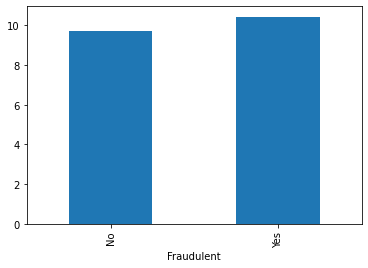

In [93]:
#Merchant_Location_History vs Fraudulent
financial_data_target_categorical.groupby('Fraudulent')['Merchant_Location_History'].mean().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Merchant_Location_History'].mean()

Fraudulent
No     10
Yes    10
Name: Merchant_Location_History, dtype: int64

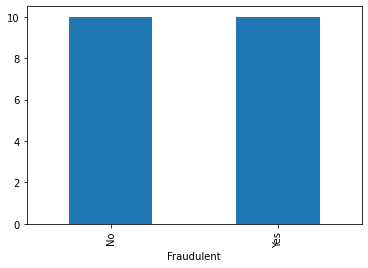

In [94]:
financial_data_target_categorical.groupby('Fraudulent')['Merchant_Location_History'].median().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Merchant_Location_History'].median()

Fraudulent,No,Yes
Merchant_Location_History_bin,,
"(1, 6]",0.949821,0.050179
"(6, 11]",0.941392,0.058608
"(11, 15]",0.937799,0.062201
"(15, 20]",0.952128,0.047872


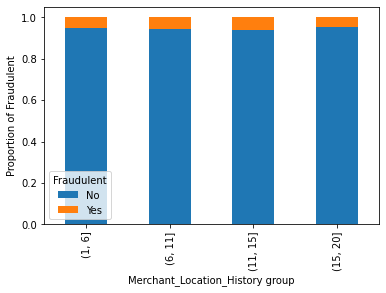

In [95]:
bins=[1,6,11,15,20]
financial_data_target_categorical['Merchant_Location_History_bin']=pd.cut(financial_data_target_categorical['Merchant_Location_History'],bins)
Merchant_Location_History_bin=pd.crosstab(financial_data_target_categorical['Merchant_Location_History_bin'],financial_data_target_categorical['Fraudulent'])
Merchant_Location_History_bin.div(Merchant_Location_History_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Merchant_Location_History group")
plt.ylabel("Proportion of Fraudulent")
Merchant_Location_History_bin.div(Merchant_Location_History_bin.sum(1).astype(float),axis=0)

We observed irrespective of Merchant_Location_History, around 5% of the records in each quarter are fraudulent.

Fraudulent
No     2738.999317
Yes    2883.894024
Name: Spending_Patterns, dtype: float64

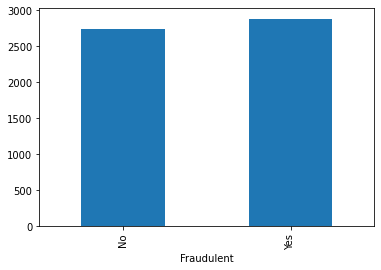

In [96]:
#Spending_Patterns vs Fraudulent
financial_data_target_categorical.groupby('Fraudulent')['Spending_Patterns'].mean().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Spending_Patterns'].mean()

Fraudulent
No     2809.878623
Yes    3057.892929
Name: Spending_Patterns, dtype: float64

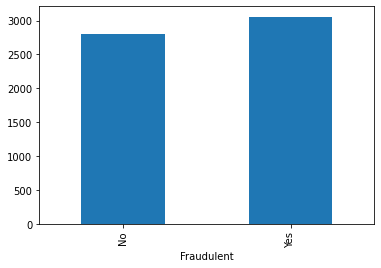

In [97]:
financial_data_target_categorical.groupby('Fraudulent')['Spending_Patterns'].median().plot.bar()
financial_data_target_categorical.groupby('Fraudulent')['Spending_Patterns'].median()

Fraudulent,No,Yes
Spending_Patterns_bin,,
"(500, 1562]",0.956,0.044
"(1562, 2840]",0.952,0.048
"(2840, 3861]",0.936,0.064
"(3861, 4995]",0.944,0.056


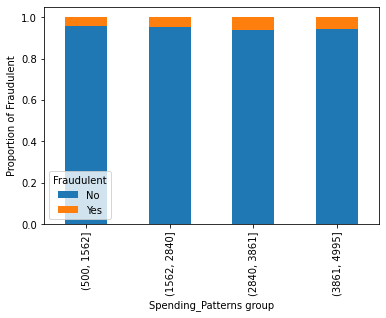

In [98]:
bins=[500,1562,2840,3861,4995]
financial_data_target_categorical['Spending_Patterns_bin']=pd.cut(financial_data_target_categorical['Spending_Patterns'],bins)
Spending_Patterns_bin=pd.crosstab(financial_data_target_categorical['Spending_Patterns_bin'],financial_data_target_categorical['Fraudulent'])
Spending_Patterns_bin.div(Spending_Patterns_bin.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True)
plt.xlabel("Spending_Patterns group")
plt.ylabel("Proportion of Fraudulent")
Spending_Patterns_bin.div(Spending_Patterns_bin.sum(1).astype(float),axis=0)

We observed maximum number of fraudulent transactions with respect to Spending Patterns are in 3rd quarter: 2840 to 3860: 6.4%

For other quarters witn respect to Spending Patterns, we observed fraudulent transactions are around 4.4% to 5.6%.

# Correlational analysis of the dataset

<Axes: >

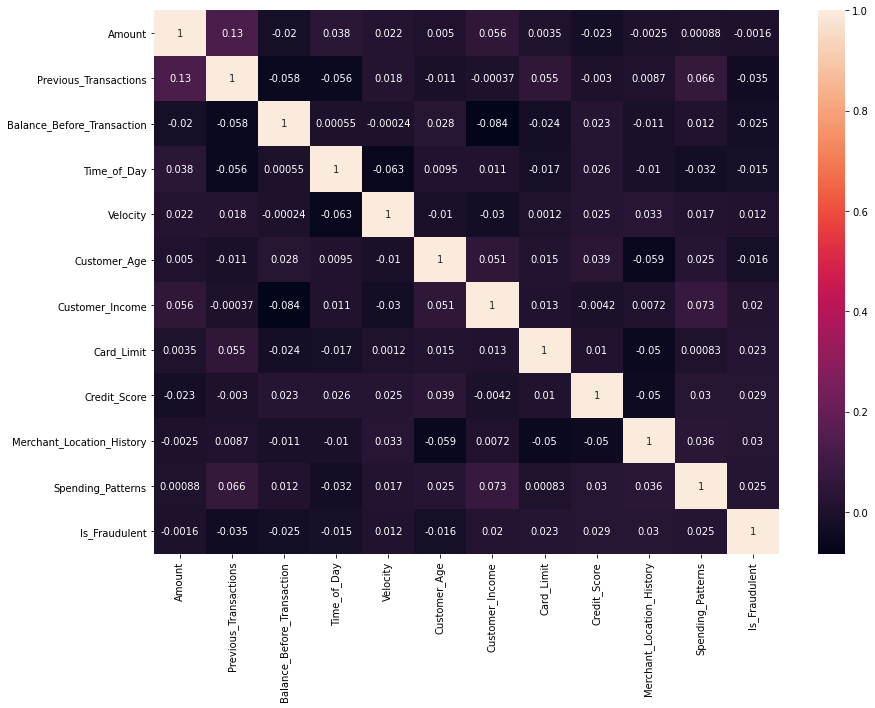

In [99]:
corr=financial_data.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr,annot=True)

From the above heatmap, we did not find any features highly correlated to each other.

# Normalizing the data

In [100]:
#Fetching a list of all column names with data type as object.
objectList=financial_data.select_dtypes(include="object").columns
print(objectList)

Index(['Date', 'Card_Type', 'MCC_Category', 'Location', 'Device',
       'Merchant_Reputation', 'Online_Transactions_Frequency'],
      dtype='object')


In [101]:
type(objectList)
objectList=list(objectList)

In [102]:
type(objectList)

list

In [103]:
#Removing the column: Date from objectList
objectList.remove("Date")
print(objectList)

['Card_Type', 'MCC_Category', 'Location', 'Device', 'Merchant_Reputation', 'Online_Transactions_Frequency']


In [104]:
#Adding a new column for fetching the value: month from Date.
financial_data.insert(18,"Month","")
financial_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Amount                         1000 non-null   float64
 1   Date                           1000 non-null   object 
 2   Card_Type                      1000 non-null   object 
 3   MCC_Category                   1000 non-null   object 
 4   Location                       1000 non-null   object 
 5   Device                         1000 non-null   object 
 6   Previous_Transactions          1000 non-null   int64  
 7   Balance_Before_Transaction     1000 non-null   float64
 8   Time_of_Day                    1000 non-null   int64  
 9   Velocity                       1000 non-null   float64
 10  Customer_Age                   1000 non-null   int64  
 11  Customer_Income                1000 non-null   float64
 12  Card_Limit                     1000 non-null   fl

In [105]:
#Extracting the value of month from Date
i=0
while(i<len(financial_data['Date'])):
    date_value=financial_data['Date'][i]
    #Extracting month from date_value
    month=date_value[5:7]
    if(month=="01"):
        financial_data['Month'][i]="Jan"
    elif(month=="02"):
        financial_data['Month'][i]="Feb"
    elif(month=="03"):
        financial_data['Month'][i]="Mar"
    elif(month=="04"):
        financial_data['Month'][i]="Apr"
    elif(month=="05"):
        financial_data['Month'][i]="May"
    elif(month=="06"):
        financial_data['Month'][i]="Jun"
    elif(month=="07"):
        financial_data['Month'][i]="Jul"
    elif(month=="08"):
        financial_data['Month'][i]="Aug"
    elif(month=="09"):
        financial_data['Month'][i]="Sep"
    elif(month=="10"):
        financial_data['Month'][i]="Oct"
    elif(month=="11"):
        financial_data['Month'][i]="Nov"
    elif(month=="12"):
        financial_data['Month'][i]="Dec"
    i=i+1

financial_data.head(5)

<ipython-input-105-f24b75dc41f3>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financial_data['Month'][i]="Jul"
<ipython-input-105-f24b75dc41f3>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financial_data['Month'][i]="Feb"
<ipython-input-105-f24b75dc41f3>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financial_data['Month'][i]="Jan"
<ipython-input-105-f24b75dc41f3>:12: SettingWithCopyWarning: 
A value is trying to be set on

,Amount,Date,Card_Type,MCC_Category,Location,Device,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Reputation,Merchant_Location_History,Spending_Patterns,Online_Transactions_Frequency,Month,Is_Fraudulent
0,180.924993,2023-07-02,Debit,Electronics,UK,Desktop,6,919.055267,10,-0.337955,52,105545.340543,2503.758986,401,Average,6,828.820298,Medium,Jul,0
1,794.625797,2023-02-18,Prepaid,Groceries,Canada,Desktop,5,3529.930762,17,0.015117,62,92651.854405,12885.681726,409,Average,13,4384.528307,Low,Feb,1
2,818.413303,2023-01-02,Prepaid,Electronics,UK,POS,5,6578.889931,4,-0.198457,42,90579.479280,2039.105869,323,Good,1,733.282224,High,Jan,0
3,530.306522,2023-03-21,Credit,Restaurants,US,Mobile,3,8036.856328,20,-0.076741,76,63777.184316,5568.880208,674,Bad,1,670.074148,High,Mar,0
4,649.101853,2023-08-28,Debit,Electronics,Canada,Desktop,4,5342.795887,16,-0.029077,39,30620.998085,6945.439545,533,Good,3,550.619875,Low,Aug,0


In [106]:
#Dropping the column: Date from financial_data
financial_data.drop(['Date'],axis=1,inplace=True)
financial_data.head(5)

,Amount,Card_Type,MCC_Category,Location,Device,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Reputation,Merchant_Location_History,Spending_Patterns,Online_Transactions_Frequency,Month,Is_Fraudulent
0,180.924993,Debit,Electronics,UK,Desktop,6,919.055267,10,-0.337955,52,105545.340543,2503.758986,401,Average,6,828.820298,Medium,Jul,0
1,794.625797,Prepaid,Groceries,Canada,Desktop,5,3529.930762,17,0.015117,62,92651.854405,12885.681726,409,Average,13,4384.528307,Low,Feb,1
2,818.413303,Prepaid,Electronics,UK,POS,5,6578.889931,4,-0.198457,42,90579.479280,2039.105869,323,Good,1,733.282224,High,Jan,0
3,530.306522,Credit,Restaurants,US,Mobile,3,8036.856328,20,-0.076741,76,63777.184316,5568.880208,674,Bad,1,670.074148,High,Mar,0
4,649.101853,Debit,Electronics,Canada,Desktop,4,5342.795887,16,-0.029077,39,30620.998085,6945.439545,533,Good,3,550.619875,Low,Aug,0


In [107]:
objectList=financial_data.select_dtypes(include="object").columns
print(objectList)

Index(['Card_Type', 'MCC_Category', 'Location', 'Device',
       'Merchant_Reputation', 'Online_Transactions_Frequency', 'Month'],
      dtype='object')


In [108]:
objectList=list(objectList)
type(objectList)

list

In [109]:
print(objectList)

['Card_Type', 'MCC_Category', 'Location', 'Device', 'Merchant_Reputation', 'Online_Transactions_Frequency', 'Month']


In [110]:
#Performing onehotencoding on the categorical data of the dataset.
one_hot_encoded_data = pd.get_dummies(financial_data, columns=objectList) 
print(one_hot_encoded_data)

         Amount  Previous_Transactions  Balance_Before_Transaction  \
0    180.924993                      6                  919.055267   
1    794.625797                      5                 3529.930762   
2    818.413303                      5                 6578.889931   
3    530.306522                      3                 8036.856328   
4    649.101853                      4                 5342.795887   
..          ...                    ...                         ...   
995  536.205566                      6                 7131.892816   
996  615.954996                      8                 6940.176274   
997  472.562610                      4                 4209.798746   
998  517.723900                      8                  496.330227   
999  489.865943                      0                 4015.643994   

     Time_of_Day  Velocity  Customer_Age  Customer_Income    Card_Limit  \
0             10 -0.337955            52    105545.340543   2503.758986   
1        

After onehotencoding, our columns count has increased to 40.
Thus, now implmenting correlational analysis over 40 columns will not help to get readable visualization.

Moreover in Bi-Variate analysis, we have analyzed most of the categorical datasets which we have encoded. 

Thus, we will take the onehotencoded columns for Month and determine if any relation exists with Is_Fraudulent.

<Axes: >

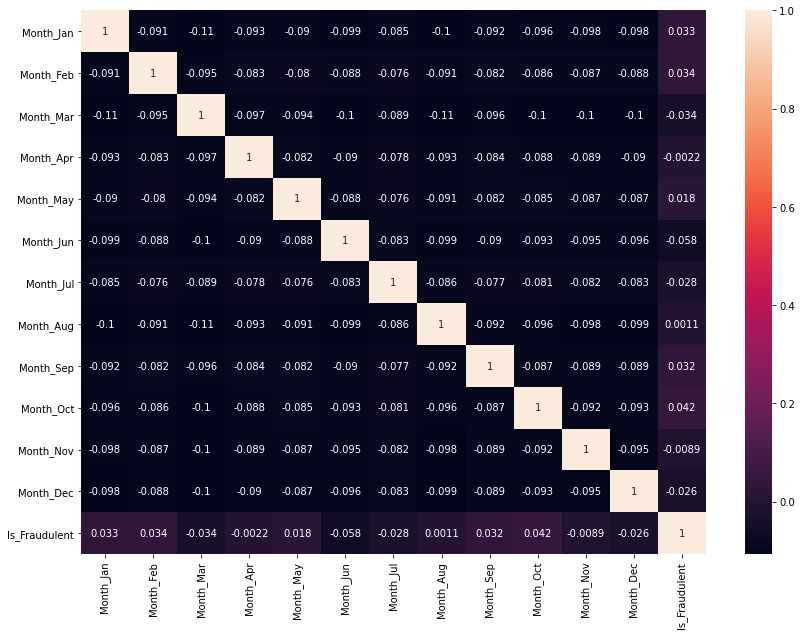

In [111]:
#We will take onehotencoded columns for Month
dataset_Location=one_hot_encoded_data[['Month_Jan','Month_Feb','Month_Mar','Month_Apr','Month_May','Month_Jun','Month_Jul','Month_Aug','Month_Sep','Month_Oct','Month_Nov','Month_Dec','Is_Fraudulent']]
corr=dataset_Location.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr,annot=True)

**We will now try to analyze hour of the day with fraudulent transactions and other categorical features.**

In [112]:
financial_data.head()

,Amount,Card_Type,MCC_Category,Location,Device,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Reputation,Merchant_Location_History,Spending_Patterns,Online_Transactions_Frequency,Month,Is_Fraudulent
0,180.924993,Debit,Electronics,UK,Desktop,6,919.055267,10,-0.337955,52,105545.340543,2503.758986,401,Average,6,828.820298,Medium,Jul,0
1,794.625797,Prepaid,Groceries,Canada,Desktop,5,3529.930762,17,0.015117,62,92651.854405,12885.681726,409,Average,13,4384.528307,Low,Feb,1
2,818.413303,Prepaid,Electronics,UK,POS,5,6578.889931,4,-0.198457,42,90579.479280,2039.105869,323,Good,1,733.282224,High,Jan,0
3,530.306522,Credit,Restaurants,US,Mobile,3,8036.856328,20,-0.076741,76,63777.184316,5568.880208,674,Bad,1,670.074148,High,Mar,0
4,649.101853,Debit,Electronics,Canada,Desktop,4,5342.795887,16,-0.029077,39,30620.998085,6945.439545,533,Good,3,550.619875,Low,Aug,0


([<matplotlib.axis.XTick at 0x22bfe9ddee0>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

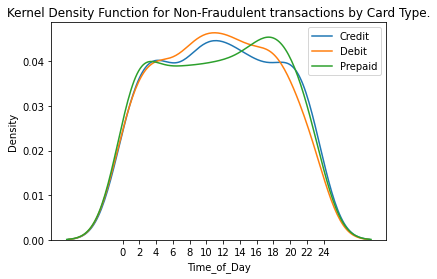

In [113]:
#Analyzing the transactions by Card_Type and Time_of_Day
sns.kdeplot(financial_data.Time_of_Day[financial_data.Card_Type=="Credit"][financial_data.Is_Fraudulent==0],label="Credit")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Card_Type=="Debit"][financial_data.Is_Fraudulent==0],label="Debit")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Card_Type=="Prepaid"][financial_data.Is_Fraudulent==0],label="Prepaid")
plt.legend()
plt.title("Kernel Density Function for Non-Fraudulent transactions by Card Type.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

([<matplotlib.axis.XTick at 0x22bfea2b0a0>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

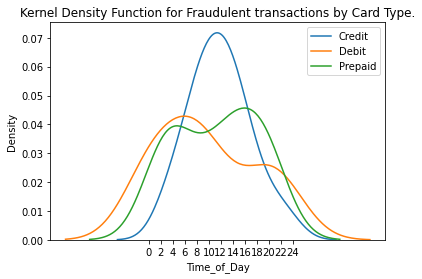

In [114]:
sns.kdeplot(financial_data.Time_of_Day[financial_data.Card_Type=="Credit"][financial_data.Is_Fraudulent==1],label="Credit")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Card_Type=="Debit"][financial_data.Is_Fraudulent==1],label="Debit")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Card_Type=="Prepaid"][financial_data.Is_Fraudulent==1],label="Prepaid")
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by Card Type.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

1. For Card_Type=Credit: -

    a. Most of the Fraudulent transactions are between 10 am and 12 pm. We observed *normal distribution* of transactions.

    b. Most of the Non-Fraudulent transactions are between 10 am and 12 pm. We do not observe normal distribution of transactions and the transactions are relatively equally spread between 2 am to 10 pm.


2. For Card_Type=Debit: -

    a. Most of the Fraudulent transactions are between 4 am and 6 am, and after 6 am we see consistent decline. And we see consistent incline from 12 am upto 4 am.

    b. Most of the Non-Fraudulent transactions are between 8 am and 10 am. We see relatively consistent transactions between 4 am and 6 pm.


3. For Card_Type=Prepaid: -

    a. Most of the Fraudulent transactions are between 4 pm and 6 pm. The next highest number of Fraudulent transactions are observed between 4 am and 6 am. We observed a steady incline from 12 am to 4 am. Then we observed a steady incline from 12 pm to 6 pm, and after 6 pm we see a steady decline.

    b. Most of the Non-Fraudulent transactions are between 4 pm and 6 pm. We also observe next highest number of Non-Fraudulent transactions between 2 am and 4 am. Between 4 am to 6 pm, we observed a steady incline.

([<matplotlib.axis.XTick at 0x22bfebb41c0>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

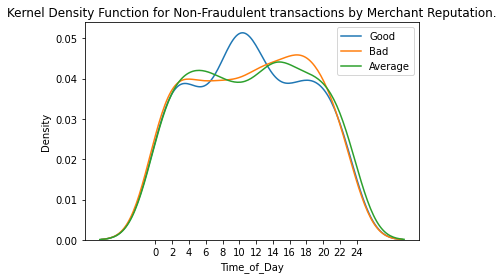

In [115]:
#Analyzing the transactions by Merchant_Reputation and Time_of_Day
sns.kdeplot(financial_data.Time_of_Day[financial_data.Merchant_Reputation=="Good"][financial_data.Is_Fraudulent==0],label="Good")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Merchant_Reputation=="Bad"][financial_data.Is_Fraudulent==0],label="Bad")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Merchant_Reputation=="Average"][financial_data.Is_Fraudulent==0],label="Average")
plt.legend()
plt.title("Kernel Density Function for Non-Fraudulent transactions by Merchant Reputation.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

([<matplotlib.axis.XTick at 0x22bfe9a98b0>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

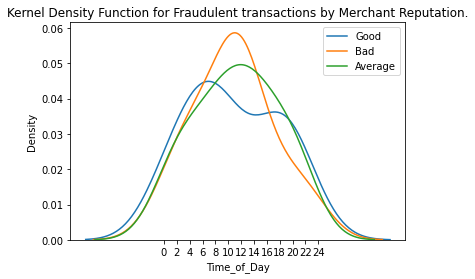

In [116]:
sns.kdeplot(financial_data.Time_of_Day[financial_data.Merchant_Reputation=="Good"][financial_data.Is_Fraudulent==1],label="Good")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Merchant_Reputation=="Bad"][financial_data.Is_Fraudulent==1],label="Bad")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Merchant_Reputation=="Average"][financial_data.Is_Fraudulent==1],label="Average")
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by Merchant Reputation.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

1. For Merchant_Reputation=Good: -

    a. Most of the Fraudulent transactions are between 4 am and 6 am. From 12 am to 4 am, we observe steady incline. And after 6 am, we observe a steady decline.

    b. Most of the Non-Fraudulent transactions are between 10 am and 12 pm. We also observe incline from 12 am to 2 am and then from 6 am to 10 am. We observe a dcline from 12 pm to 4 pm and then from 6 pm till end of the day.


2. For Merchant_Reputation=Average: -

    a. Most of the Fraudulent transactions are around 12 pm. We observe normal distribution of the graph.

    b. We see incline in Non-Fraudulent transactions from 12 am to 4 am, and decline from 4 pm till end of the day.


3. For Merchant_Reputation=Bad: -

    a. Most of the Fraudulent transactions are between 10 am and 12 pm. We observe normal distribution of the graph.

    b. We see incline in Non-Fraudulent transactions between 3 am and 5 pm.

([<matplotlib.axis.XTick at 0x22bfee8f5b0>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

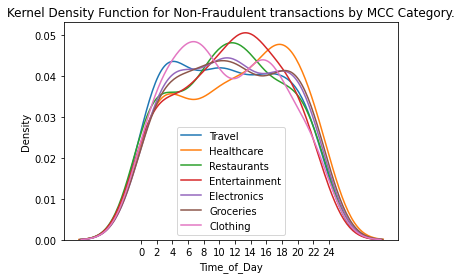

In [117]:
#Analyzing the transactions by MCC_Category and Time_of_Day
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Travel"][financial_data.Is_Fraudulent==0],label="Travel")
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Healthcare"][financial_data.Is_Fraudulent==0],label="Healthcare")
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Restaurants"][financial_data.Is_Fraudulent==0],label="Restaurants")
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Entertainment"][financial_data.Is_Fraudulent==0],label="Entertainment")
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Electronics"][financial_data.Is_Fraudulent==0],label="Electronics")
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Groceries"][financial_data.Is_Fraudulent==0],label="Groceries")
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Clothing"][financial_data.Is_Fraudulent==0],label="Clothing")
plt.legend()
plt.title("Kernel Density Function for Non-Fraudulent transactions by MCC Category.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

([<matplotlib.axis.XTick at 0x22bfef44670>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

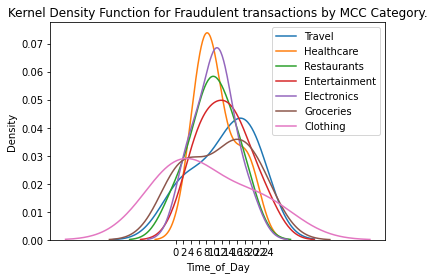

In [118]:
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Travel"][financial_data.Is_Fraudulent==1],label="Travel")
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Healthcare"][financial_data.Is_Fraudulent==1],label="Healthcare")
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Restaurants"][financial_data.Is_Fraudulent==1],label="Restaurants")
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Entertainment"][financial_data.Is_Fraudulent==1],label="Entertainment")
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Electronics"][financial_data.Is_Fraudulent==1],label="Electronics")
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Groceries"][financial_data.Is_Fraudulent==1],label="Groceries")
sns.kdeplot(financial_data.Time_of_Day[financial_data.MCC_Category=="Clothing"][financial_data.Is_Fraudulent==1],label="Clothing")
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by MCC Category.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

1. Most of the Fraudulent transactions for below MCC_Category were observed between 8 am and 12 pm: -

    a. Healthcare

    b. Electronics

    c. Restaurants

    d. Entertainment


2. Most of Fraudulent transactions for MCC_Category=Clothing were observed between 2 am and 4 am.


3. Most of the Fraudulent transactions for below MCC_Category were observed between 4 pm and 6 pm: -

    a. Travel

    b. Groceries

([<matplotlib.axis.XTick at 0x22bff009310>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

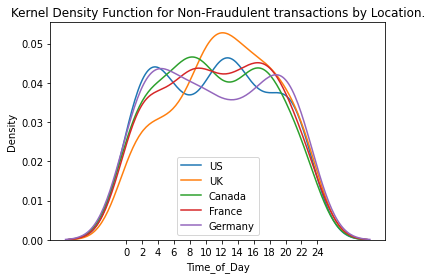

In [119]:
#Analyzing the transactions by Location and Time_of_Day
sns.kdeplot(financial_data.Time_of_Day[financial_data.Location=="US"][financial_data.Is_Fraudulent==0],label="US")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Location=="UK"][financial_data.Is_Fraudulent==0],label="UK")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Location=="Canada"][financial_data.Is_Fraudulent==0],label="Canada")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Location=="France"][financial_data.Is_Fraudulent==0],label="France")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Location=="Germany"][financial_data.Is_Fraudulent==0],label="Germany")
plt.legend()
plt.title("Kernel Density Function for Non-Fraudulent transactions by Location.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

([<matplotlib.axis.XTick at 0x22bff0aaaf0>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

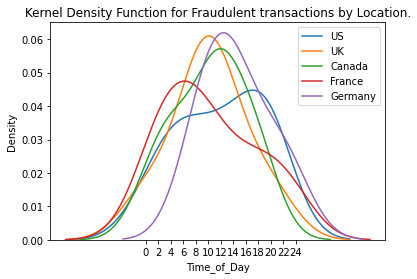

In [120]:
sns.kdeplot(financial_data.Time_of_Day[financial_data.Location=="US"][financial_data.Is_Fraudulent==1],label="US")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Location=="UK"][financial_data.Is_Fraudulent==1],label="UK")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Location=="Canada"][financial_data.Is_Fraudulent==1],label="Canada")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Location=="France"][financial_data.Is_Fraudulent==1],label="France")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Location=="Germany"][financial_data.Is_Fraudulent==1],label="Germany")
plt.legend()
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by Location.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

1. We observed for France the data is left skewed, and thus, more number of Fraudulent transactions are observed in early hours: 12 am to 5 am.


2. We observed for US the data is right skewed, and thus, more number of Fraudulent transactions are onbserved on second half: 5 pm to 7 pm.


3. For other countries: UK, Canada, Germany, we observed a fairly *Normal distribution*.

    a. For UK, the maximum Fraudulent transactions are between 8 am and 10 am.
    
    b. For Canada and Germany, the maximum Fraudulent transactions are between 12 pm to 2 pm.

([<matplotlib.axis.XTick at 0x22bff6f6880>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

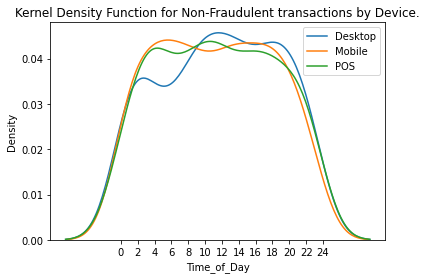

In [121]:
#Analyzing the transactions by Device and Time_of_Day
sns.kdeplot(financial_data.Time_of_Day[financial_data.Device=="Desktop"][financial_data.Is_Fraudulent==0],label="Desktop")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Device=="Mobile"][financial_data.Is_Fraudulent==0],label="Mobile")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Device=="POS"][financial_data.Is_Fraudulent==0],label="POS")
plt.legend()
plt.title("Kernel Density Function for Non-Fraudulent transactions by Device.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

([<matplotlib.axis.XTick at 0x22bff77bd60>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

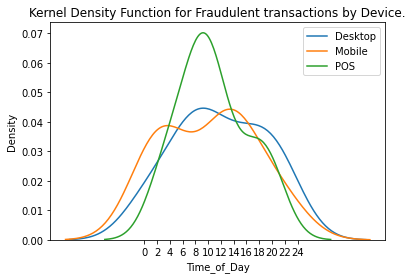

In [122]:
sns.kdeplot(financial_data.Time_of_Day[financial_data.Device=="Desktop"][financial_data.Is_Fraudulent==1],label="Desktop")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Device=="Mobile"][financial_data.Is_Fraudulent==1],label="Mobile")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Device=="POS"][financial_data.Is_Fraudulent==1],label="POS")
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by Device.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

1. We observed most Fraudulent transactions for Device=POS are between 8 am to 10 am. Moreover, we observed the graph is *Normal distribution.*


2. For transactions with other Devices: Desktop and Mobile, there are multiple modes and thus, not very clear to identify during what time of day most fraudulent transactions are observed.


3. But, we can clearly observed the difference in occurrence of Fraudulent transactions of POS vs Desktop and Mobile.

([<matplotlib.axis.XTick at 0x22bfed7f1c0>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

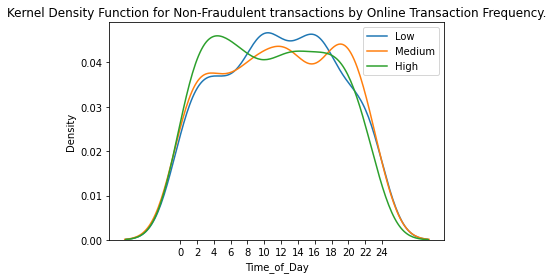

In [123]:
#Analyzing the transactions by Online_Transaction_Frequency and Time_of_Day
sns.kdeplot(financial_data.Time_of_Day[financial_data.Online_Transactions_Frequency=="Low"][financial_data.Is_Fraudulent==0],label="Low")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Online_Transactions_Frequency=="Medium"][financial_data.Is_Fraudulent==0],label="Medium")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Online_Transactions_Frequency=="High"][financial_data.Is_Fraudulent==0],label="High")
plt.legend()
plt.title("Kernel Density Function for Non-Fraudulent transactions by Online Transaction Frequency.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

([<matplotlib.axis.XTick at 0x22bff87fe50>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

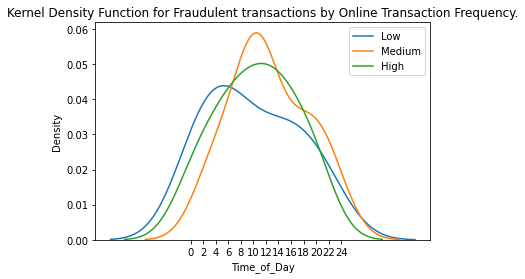

In [124]:
sns.kdeplot(financial_data.Time_of_Day[financial_data.Online_Transactions_Frequency=="Low"][financial_data.Is_Fraudulent==1],label="Low")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Online_Transactions_Frequency=="Medium"][financial_data.Is_Fraudulent==1],label="Medium")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Online_Transactions_Frequency=="High"][financial_data.Is_Fraudulent==1],label="High")
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by Online Transaction Frequency.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

1. We observed Fraudulent transactions for Online Transaction Frequency=Low is Left skewed. Thus, most number of Fraudulent transactions occur in early hours: 4 am to 6 am.


2. We observed Fraudulent trasactions for Online Transaction Frequency=Medium, High is *Normally distributed*. Most number of Fraudulent transactions for both the categories are between 10 am to 12 pm.

    a. The graph for Online_Transaction_Frequency=Medium has smaller Standard Deviation than the graph for Online_Transaction_Frequency=High. We infer this from observing width of the curves between the two graphs. 
    
    b. Thus we see more dispersion for Online_Transaction_Frequency=High than for Online_Transaction_Frequency=Medium.

([<matplotlib.axis.XTick at 0x22bff92d1f0>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

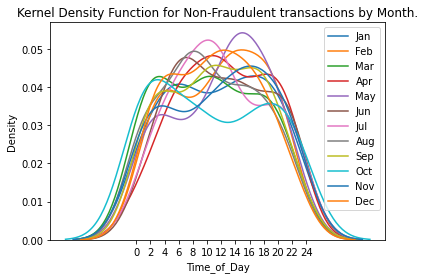

In [125]:
#Analyzing the transactions by Month and Time_of_Day
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Jan"][financial_data.Is_Fraudulent==0],label="Jan")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Feb"][financial_data.Is_Fraudulent==0],label="Feb")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Mar"][financial_data.Is_Fraudulent==0],label="Mar")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Apr"][financial_data.Is_Fraudulent==0],label="Apr")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="May"][financial_data.Is_Fraudulent==0],label="May")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Jun"][financial_data.Is_Fraudulent==0],label="Jun")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Jul"][financial_data.Is_Fraudulent==0],label="Jul")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Aug"][financial_data.Is_Fraudulent==0],label="Aug")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Sep"][financial_data.Is_Fraudulent==0],label="Sep")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Oct"][financial_data.Is_Fraudulent==0],label="Oct")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Nov"][financial_data.Is_Fraudulent==0],label="Nov")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Dec"][financial_data.Is_Fraudulent==0],label="Dec")
plt.legend()
plt.title("Kernel Density Function for Non-Fraudulent transactions by Month.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

C:\Users\pc\anaconda3\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


([<matplotlib.axis.XTick at 0x22bffa10700>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

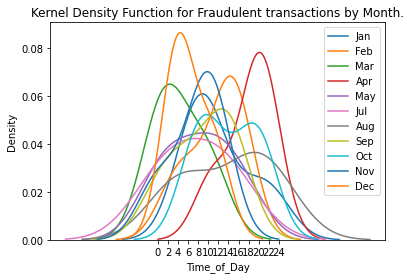

In [126]:
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Jan"][financial_data.Is_Fraudulent==1],label="Jan")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Feb"][financial_data.Is_Fraudulent==1],label="Feb")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Mar"][financial_data.Is_Fraudulent==1],label="Mar")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Apr"][financial_data.Is_Fraudulent==1],label="Apr")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="May"][financial_data.Is_Fraudulent==1],label="May")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Jun"][financial_data.Is_Fraudulent==1],label="Jun")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Jul"][financial_data.Is_Fraudulent==1],label="Jul")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Aug"][financial_data.Is_Fraudulent==1],label="Aug")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Sep"][financial_data.Is_Fraudulent==1],label="Sep")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Oct"][financial_data.Is_Fraudulent==1],label="Oct")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Nov"][financial_data.Is_Fraudulent==1],label="Nov")
sns.kdeplot(financial_data.Time_of_Day[financial_data.Month=="Dec"][financial_data.Is_Fraudulent==1],label="Dec")
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by Month.")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20,22,24])

1. We observed the Fraudulent transactions for each month have *Normal distribution*.


2. April has right skewed data.


3. Februray and March have left skewed data.


4. However, each month has it own peak and thus, we cannot make a general conclusion which time of the day is having most Fraudulent transactions.

## Summary from above KDE plots

We observed **Time_of_Day** plays a significant role in classifying or determining the likelihood of most number of Fraudulent transactions across different categorical features.

**We will now try to analyze customer age with fraudulent transactions and other categorical features.**

([<matplotlib.axis.XTick at 0x22bffb18f40>,
 [Text(10, 0, '10'),
  Text(20, 0, '20'),
  Text(30, 0, '30'),
  Text(40, 0, '40'),
  Text(50, 0, '50'),
  Text(60, 0, '60'),
  Text(70, 0, '70'),
  Text(80, 0, '80'),
  Text(90, 0, '90'),
  Text(100, 0, '100')])

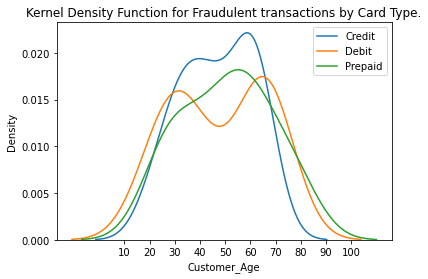

In [127]:
sns.kdeplot(financial_data.Customer_Age[financial_data.Card_Type=="Credit"][financial_data.Is_Fraudulent==1],label="Credit")
sns.kdeplot(financial_data.Customer_Age[financial_data.Card_Type=="Debit"][financial_data.Is_Fraudulent==1],label="Debit")
sns.kdeplot(financial_data.Customer_Age[financial_data.Card_Type=="Prepaid"][financial_data.Is_Fraudulent==1],label="Prepaid")
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by Card Type.")
plt.xticks([10,20,30,40,50,60,70,80,90,100])

1. Fraudulent transactions of Card Type=Debit have 2 modes: Age 20 to 30 and Age 60 to 70.


2. Fraudulent transactions of Card Type=Prepaid is right skewed, and the maximum count is between Age 50 to 60.


3. Fraudulent transactions of Card Type=Credit is right skewed, and the maximum count is around Age 60.

([<matplotlib.axis.XTick at 0x22bffba6820>,
 [Text(10, 0, '10'),
  Text(20, 0, '20'),
  Text(30, 0, '30'),
  Text(40, 0, '40'),
  Text(50, 0, '50'),
  Text(60, 0, '60'),
  Text(70, 0, '70'),
  Text(80, 0, '80'),
  Text(90, 0, '90'),
  Text(100, 0, '100')])

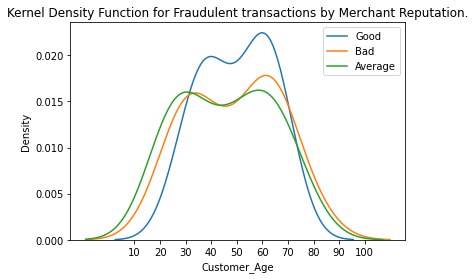

In [128]:
sns.kdeplot(financial_data.Customer_Age[financial_data.Merchant_Reputation=="Good"][financial_data.Is_Fraudulent==1],label="Good")
sns.kdeplot(financial_data.Customer_Age[financial_data.Merchant_Reputation=="Bad"][financial_data.Is_Fraudulent==1],label="Bad")
sns.kdeplot(financial_data.Customer_Age[financial_data.Merchant_Reputation=="Average"][financial_data.Is_Fraudulent==1],label="Average")
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by Merchant Reputation.")
plt.xticks([10,20,30,40,50,60,70,80,90,100])

1. We see for all three types of Merchant Reputation, we have multiple modes.


2. For Merchant Reputation=Good, we observed top two age groups with most Fraudulent transactions are: - 

    a. Around customer age 60
    
    b. Between customer age 30 to 40
    

3. For Merchant Reputation=Average, we observed top two age groups with most Fraudulent transactions are: - 

    a. Around customer age 30
    
    b. Around customer age 60
    

4. For Merchant Reputation=Bad, we observed top two age groups with most Fraudulent transactions are: -

    a. Between customer age 30 to 40
    
    b. Between customer age 60 to 70
    
    
5. Between age 30 to 40, we see more number of Fraudulent transaction with Merchant_Reputation=Good than Merchant_Reputation=Bad.

([<matplotlib.axis.XTick at 0x22bffc39850>,
 [Text(10, 0, '10'),
  Text(20, 0, '20'),
  Text(30, 0, '30'),
  Text(40, 0, '40'),
  Text(50, 0, '50'),
  Text(60, 0, '60'),
  Text(70, 0, '70'),
  Text(80, 0, '80'),
  Text(90, 0, '90'),
  Text(100, 0, '100')])

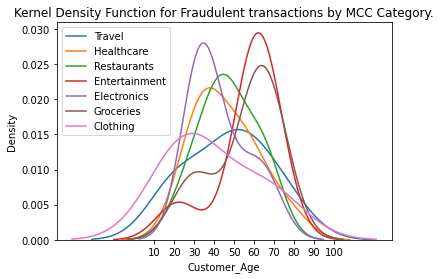

In [129]:
sns.kdeplot(financial_data.Customer_Age[financial_data.MCC_Category=="Travel"][financial_data.Is_Fraudulent==1],label="Travel")
sns.kdeplot(financial_data.Customer_Age[financial_data.MCC_Category=="Healthcare"][financial_data.Is_Fraudulent==1],label="Healthcare")
sns.kdeplot(financial_data.Customer_Age[financial_data.MCC_Category=="Restaurants"][financial_data.Is_Fraudulent==1],label="Restaurants")
sns.kdeplot(financial_data.Customer_Age[financial_data.MCC_Category=="Entertainment"][financial_data.Is_Fraudulent==1],label="Entertainment")
sns.kdeplot(financial_data.Customer_Age[financial_data.MCC_Category=="Electronics"][financial_data.Is_Fraudulent==1],label="Electronics")
sns.kdeplot(financial_data.Customer_Age[financial_data.MCC_Category=="Groceries"][financial_data.Is_Fraudulent==1],label="Groceries")
sns.kdeplot(financial_data.Customer_Age[financial_data.MCC_Category=="Clothing"][financial_data.Is_Fraudulent==1],label="Clothing")
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by MCC Category.")
plt.xticks([10,20,30,40,50,60,70,80,90,100])

We observed each type of MCC Category has its own maximum fraudulent transactions on different age group of customers.


For example: -


1. For MCC_category=Entertainment, maximum fraudulent transactions are around customer age=60


2. For MCC_category=Clothing, maximum fraudulent transactions are between age 20 to 30.

([<matplotlib.axis.XTick at 0x22bffcf0df0>,
 [Text(10, 0, '10'),
  Text(20, 0, '20'),
  Text(30, 0, '30'),
  Text(40, 0, '40'),
  Text(50, 0, '50'),
  Text(60, 0, '60'),
  Text(70, 0, '70'),
  Text(80, 0, '80'),
  Text(90, 0, '90'),
  Text(100, 0, '100')])

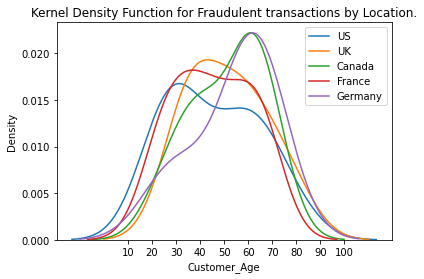

In [130]:
sns.kdeplot(financial_data.Customer_Age[financial_data.Location=="US"][financial_data.Is_Fraudulent==1],label="US")
sns.kdeplot(financial_data.Customer_Age[financial_data.Location=="UK"][financial_data.Is_Fraudulent==1],label="UK")
sns.kdeplot(financial_data.Customer_Age[financial_data.Location=="Canada"][financial_data.Is_Fraudulent==1],label="Canada")
sns.kdeplot(financial_data.Customer_Age[financial_data.Location=="France"][financial_data.Is_Fraudulent==1],label="France")
sns.kdeplot(financial_data.Customer_Age[financial_data.Location=="Germany"][financial_data.Is_Fraudulent==1],label="Germany")
plt.legend()
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by Location.")
plt.xticks([10,20,30,40,50,60,70,80,90,100])

1. In US most fraudulent transactions are around customer age 30.


2. In UK most fraudulent transactions are around customer age 40.


3. In Canada most fraudulent transactions are between customer age 60 to 70.


4. In France, top two age groups with most fraudulent transactions are: -

    a. Customer age between 30 to 40
    
    b. Customer age around 60
    

5. In Germany most fraudulent transactions are between customer age 60 to 70.

([<matplotlib.axis.XTick at 0x22bffda4c40>,
 [Text(10, 0, '10'),
  Text(20, 0, '20'),
  Text(30, 0, '30'),
  Text(40, 0, '40'),
  Text(50, 0, '50'),
  Text(60, 0, '60'),
  Text(70, 0, '70'),
  Text(80, 0, '80'),
  Text(90, 0, '90'),
  Text(100, 0, '100')])

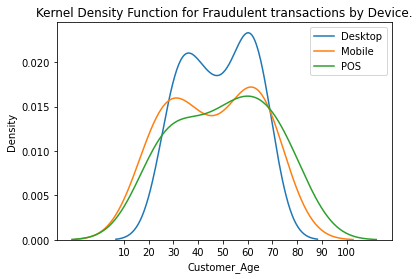

In [131]:
sns.kdeplot(financial_data.Customer_Age[financial_data.Device=="Desktop"][financial_data.Is_Fraudulent==1],label="Desktop")
sns.kdeplot(financial_data.Customer_Age[financial_data.Device=="Mobile"][financial_data.Is_Fraudulent==1],label="Mobile")
sns.kdeplot(financial_data.Customer_Age[financial_data.Device=="POS"][financial_data.Is_Fraudulent==1],label="POS")
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by Device.")
plt.xticks([10,20,30,40,50,60,70,80,90,100])

1. For Device=Desktop, we have two modes.

    a. Between customer age 30 to 40
    
    b. Between customer age 60 to 70
    
    
2. For Device=Mobile, we have two modes: -

    a. Between customer age 20 to 30
    
    b. Between customer age 60 to 70
    

3. Between customer age 60 to 70, we observed relatively more number fraudulent transactions with Device=Desktop.

([<matplotlib.axis.XTick at 0x22bffd73520>,
 [Text(10, 0, '10'),
  Text(20, 0, '20'),
  Text(30, 0, '30'),
  Text(40, 0, '40'),
  Text(50, 0, '50'),
  Text(60, 0, '60'),
  Text(70, 0, '70'),
  Text(80, 0, '80'),
  Text(90, 0, '90'),
  Text(100, 0, '100')])

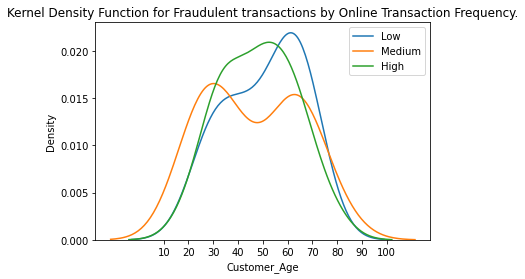

In [132]:
sns.kdeplot(financial_data.Customer_Age[financial_data.Online_Transactions_Frequency=="Low"][financial_data.Is_Fraudulent==1],label="Low")
sns.kdeplot(financial_data.Customer_Age[financial_data.Online_Transactions_Frequency=="Medium"][financial_data.Is_Fraudulent==1],label="Medium")
sns.kdeplot(financial_data.Customer_Age[financial_data.Online_Transactions_Frequency=="High"][financial_data.Is_Fraudulent==1],label="High")
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by Online Transaction Frequency.")
plt.xticks([10,20,30,40,50,60,70,80,90,100])

We observed the data for fraudulent transactions is very dispersed across Customer Age when checked with Online Transaction Frequency.

C:\Users\pc\anaconda3\lib\site-packages\seaborn\distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


([<matplotlib.axis.XTick at 0x22bffe040d0>,
 [Text(10, 0, '10'),
  Text(20, 0, '20'),
  Text(30, 0, '30'),
  Text(40, 0, '40'),
  Text(50, 0, '50'),
  Text(60, 0, '60'),
  Text(70, 0, '70'),
  Text(80, 0, '80'),
  Text(90, 0, '90'),
  Text(100, 0, '100')])

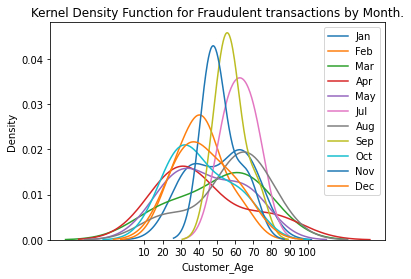

In [133]:
sns.kdeplot(financial_data.Customer_Age[financial_data.Month=="Jan"][financial_data.Is_Fraudulent==1],label="Jan")
sns.kdeplot(financial_data.Customer_Age[financial_data.Month=="Feb"][financial_data.Is_Fraudulent==1],label="Feb")
sns.kdeplot(financial_data.Customer_Age[financial_data.Month=="Mar"][financial_data.Is_Fraudulent==1],label="Mar")
sns.kdeplot(financial_data.Customer_Age[financial_data.Month=="Apr"][financial_data.Is_Fraudulent==1],label="Apr")
sns.kdeplot(financial_data.Customer_Age[financial_data.Month=="May"][financial_data.Is_Fraudulent==1],label="May")
sns.kdeplot(financial_data.Customer_Age[financial_data.Month=="Jun"][financial_data.Is_Fraudulent==1],label="Jun")
sns.kdeplot(financial_data.Customer_Age[financial_data.Month=="Jul"][financial_data.Is_Fraudulent==1],label="Jul")
sns.kdeplot(financial_data.Customer_Age[financial_data.Month=="Aug"][financial_data.Is_Fraudulent==1],label="Aug")
sns.kdeplot(financial_data.Customer_Age[financial_data.Month=="Sep"][financial_data.Is_Fraudulent==1],label="Sep")
sns.kdeplot(financial_data.Customer_Age[financial_data.Month=="Oct"][financial_data.Is_Fraudulent==1],label="Oct")
sns.kdeplot(financial_data.Customer_Age[financial_data.Month=="Nov"][financial_data.Is_Fraudulent==1],label="Nov")
sns.kdeplot(financial_data.Customer_Age[financial_data.Month=="Dec"][financial_data.Is_Fraudulent==1],label="Dec")
plt.legend()
plt.title("Kernel Density Function for Fraudulent transactions by Month.")
plt.xticks([10,20,30,40,50,60,70,80,90,100])

We observed each month has its own peak for differenet customer age groups.

## Summary from above KDE plots

We observed Customer_Age plays a significant role in classifying or determining the likelihood of most number of Fraudulent transactions across some of the categorical features.

In [134]:
financial_data.head()

,Amount,Card_Type,MCC_Category,Location,Device,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Reputation,Merchant_Location_History,Spending_Patterns,Online_Transactions_Frequency,Month,Is_Fraudulent
0,180.924993,Debit,Electronics,UK,Desktop,6,919.055267,10,-0.337955,52,105545.340543,2503.758986,401,Average,6,828.820298,Medium,Jul,0
1,794.625797,Prepaid,Groceries,Canada,Desktop,5,3529.930762,17,0.015117,62,92651.854405,12885.681726,409,Average,13,4384.528307,Low,Feb,1
2,818.413303,Prepaid,Electronics,UK,POS,5,6578.889931,4,-0.198457,42,90579.479280,2039.105869,323,Good,1,733.282224,High,Jan,0
3,530.306522,Credit,Restaurants,US,Mobile,3,8036.856328,20,-0.076741,76,63777.184316,5568.880208,674,Bad,1,670.074148,High,Mar,0
4,649.101853,Debit,Electronics,Canada,Desktop,4,5342.795887,16,-0.029077,39,30620.998085,6945.439545,533,Good,3,550.619875,Low,Aug,0


# Data Preprocessing and Cleaning

In [135]:
#List of all categorical features
print(objectList)

['Card_Type', 'MCC_Category', 'Location', 'Device', 'Merchant_Reputation', 'Online_Transactions_Frequency', 'Month']


From above features list, we have two features for label encoding: -


1. Merchant_Reputation: Good, Average, Bad


2. Online_Transaction_Frequency: High, Medium, Low


Remaining features are to be applied with onehotencoding.

In [136]:
#Categories for label encoding
label_objectList=['Merchant_Reputation','Online_Transaction_Frequency']
print("List of categorical columns for Label encoding: ",label_objectList)

#Categories for onehotencoding
onehotencoding_objectList=['Card_Type','MCC_Category','Location','Device','Month']
print("List of categorical columns for OneHotEncoding: ",onehotencoding_objectList)

List of categorical columns for Label encoding:  ['Merchant_Reputation', 'Online_Transaction_Frequency']
List of categorical columns for OneHotEncoding:  ['Card_Type', 'MCC_Category', 'Location', 'Device', 'Month']


## OneHotEncoding

In [137]:
financial_data = pd.get_dummies(financial_data, columns=onehotencoding_objectList)
financial_data.columns

Index(['Amount', 'Previous_Transactions', 'Balance_Before_Transaction',
       'Time_of_Day', 'Velocity', 'Customer_Age', 'Customer_Income',
       'Card_Limit', 'Credit_Score', 'Merchant_Reputation',
       'Merchant_Location_History', 'Spending_Patterns',
       'Online_Transactions_Frequency', 'Is_Fraudulent', 'Card_Type_Credit',
       'Card_Type_Debit', 'Card_Type_Prepaid', 'MCC_Category_Clothing',
       'MCC_Category_Electronics', 'MCC_Category_Entertainment',
       'MCC_Category_Groceries', 'MCC_Category_Healthcare',
       'MCC_Category_Restaurants', 'MCC_Category_Travel', 'Location_Canada',
       'Location_France', 'Location_Germany', 'Location_UK', 'Location_US',
       'Device_Desktop', 'Device_Mobile', 'Device_POS', 'Month_Apr',
       'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jan', 'Month_Jul',
       'Month_Jun', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct',
       'Month_Sep'],
      dtype='object')

In [138]:
financial_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Amount                         1000 non-null   float64
 1   Previous_Transactions          1000 non-null   int64  
 2   Balance_Before_Transaction     1000 non-null   float64
 3   Time_of_Day                    1000 non-null   int64  
 4   Velocity                       1000 non-null   float64
 5   Customer_Age                   1000 non-null   int64  
 6   Customer_Income                1000 non-null   float64
 7   Card_Limit                     1000 non-null   float64
 8   Credit_Score                   1000 non-null   int64  
 9   Merchant_Reputation            1000 non-null   object 
 10  Merchant_Location_History      1000 non-null   int64  
 11  Spending_Patterns              1000 non-null   float64
 12  Online_Transactions_Frequency  1000 non-null   ob

## Label Encoding

In [139]:
#Adding a new column for storing label encoded data for Merchant_Reputation.
financial_data.insert(42,"Merchant_Rep",0)
financial_data.head()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Reputation,...,Month_Feb,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Merchant_Rep,Month_Oct,Month_Sep
0,180.924993,6,919.055267,10,-0.337955,52,105545.340543,2503.758986,401,Average,...,0,0,1,0,0,0,0,0,0,0
1,794.625797,5,3529.930762,17,0.015117,62,92651.854405,12885.681726,409,Average,...,1,0,0,0,0,0,0,0,0,0
2,818.413303,5,6578.889931,4,-0.198457,42,90579.479280,2039.105869,323,Good,...,0,1,0,0,0,0,0,0,0,0
3,530.306522,3,8036.856328,20,-0.076741,76,63777.184316,5568.880208,674,Bad,...,0,0,0,0,1,0,0,0,0,0
4,649.101853,4,5342.795887,16,-0.029077,39,30620.998085,6945.439545,533,Good,...,0,0,0,0,0,0,0,0,0,0


In [140]:
#Adding a new column for storing the label encoded data for Online_Transactions_Frequency.
financial_data.insert(42,"Online_Transactions_Freq",0)
financial_data.head()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Reputation,...,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Online_Transactions_Freq,Merchant_Rep,Month_Oct,Month_Sep
0,180.924993,6,919.055267,10,-0.337955,52,105545.340543,2503.758986,401,Average,...,0,1,0,0,0,0,0,0,0,0
1,794.625797,5,3529.930762,17,0.015117,62,92651.854405,12885.681726,409,Average,...,0,0,0,0,0,0,0,0,0,0
2,818.413303,5,6578.889931,4,-0.198457,42,90579.479280,2039.105869,323,Good,...,1,0,0,0,0,0,0,0,0,0
3,530.306522,3,8036.856328,20,-0.076741,76,63777.184316,5568.880208,674,Bad,...,0,0,0,1,0,0,0,0,0,0
4,649.101853,4,5342.795887,16,-0.029077,39,30620.998085,6945.439545,533,Good,...,0,0,0,0,0,0,0,0,0,0


In [141]:
i=0
while(i<len(financial_data['Merchant_Reputation'])):
    if(financial_data['Merchant_Reputation'][i]=="Good"):
        financial_data['Merchant_Rep'][i]=0
    elif(financial_data['Merchant_Reputation'][i]=="Average"):
        financial_data['Merchant_Rep'][i]=1
    elif(financial_data['Merchant_Reputation'][i]=="Bad"):
        financial_data['Merchant_Rep'][i]=2
    i=i+1

<ipython-input-141-847a7e67457b>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financial_data['Merchant_Rep'][i]=1
<ipython-input-141-847a7e67457b>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financial_data['Merchant_Rep'][i]=0
<ipython-input-141-847a7e67457b>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financial_data['Merchant_Rep'][i]=2


In [142]:
financial_data['Merchant_Rep'].unique()

array([1, 0, 2], dtype=int64)

In [143]:
financial_data.loc[:,"Merchant_Rep"]

0      1
1      1
2      0
3      2
4      0
      ..
995    1
996    2
997    1
998    0
999    1
Name: Merchant_Rep, Length: 1000, dtype: int64

In [144]:
i=0
while(i<len(financial_data['Online_Transactions_Frequency'])):
    if(financial_data['Online_Transactions_Frequency'][i]=="High"):
        financial_data['Online_Transactions_Freq'][i]=0
    elif(financial_data['Online_Transactions_Frequency'][i]=="Medium"):
        financial_data['Online_Transactions_Freq'][i]=1
    elif(financial_data['Online_Transactions_Frequency'][i]=="Low"):
        financial_data['Online_Transactions_Freq'][i]=2
    i=i+1

<ipython-input-144-fdcc17347bd8>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financial_data['Online_Transactions_Freq'][i]=1
<ipython-input-144-fdcc17347bd8>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financial_data['Online_Transactions_Freq'][i]=2
<ipython-input-144-fdcc17347bd8>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financial_data['Online_Transactions_Freq'][i]=0


In [145]:
financial_data['Online_Transactions_Freq'].unique()

array([1, 2, 0], dtype=int64)

In [146]:
financial_data.loc[:,"Online_Transactions_Freq"]

0      1
1      2
2      0
3      0
4      2
      ..
995    0
996    0
997    2
998    2
999    1
Name: Online_Transactions_Freq, Length: 1000, dtype: int64

In [147]:
#Removal of the existing categorical columns: Merchant_Reputation, Online_Transactions_Frequency
financial_data.drop(['Merchant_Reputation','Online_Transactions_Frequency'],axis=1,inplace=True)
financial_data.columns

Index(['Amount', 'Previous_Transactions', 'Balance_Before_Transaction',
       'Time_of_Day', 'Velocity', 'Customer_Age', 'Customer_Income',
       'Card_Limit', 'Credit_Score', 'Merchant_Location_History',
       'Spending_Patterns', 'Is_Fraudulent', 'Card_Type_Credit',
       'Card_Type_Debit', 'Card_Type_Prepaid', 'MCC_Category_Clothing',
       'MCC_Category_Electronics', 'MCC_Category_Entertainment',
       'MCC_Category_Groceries', 'MCC_Category_Healthcare',
       'MCC_Category_Restaurants', 'MCC_Category_Travel', 'Location_Canada',
       'Location_France', 'Location_Germany', 'Location_UK', 'Location_US',
       'Device_Desktop', 'Device_Mobile', 'Device_POS', 'Month_Apr',
       'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jan', 'Month_Jul',
       'Month_Jun', 'Month_Mar', 'Month_May', 'Month_Nov',
       'Online_Transactions_Freq', 'Merchant_Rep', 'Month_Oct', 'Month_Sep'],
      dtype='object')

In [148]:
financial_data.head()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Location_History,...,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Online_Transactions_Freq,Merchant_Rep,Month_Oct,Month_Sep
0,180.924993,6,919.055267,10,-0.337955,52,105545.340543,2503.758986,401,6,...,0,1,0,0,0,0,1,1,0,0
1,794.625797,5,3529.930762,17,0.015117,62,92651.854405,12885.681726,409,13,...,0,0,0,0,0,0,2,1,0,0
2,818.413303,5,6578.889931,4,-0.198457,42,90579.479280,2039.105869,323,1,...,1,0,0,0,0,0,0,0,0,0
3,530.306522,3,8036.856328,20,-0.076741,76,63777.184316,5568.880208,674,1,...,0,0,0,1,0,0,0,2,0,0
4,649.101853,4,5342.795887,16,-0.029077,39,30620.998085,6945.439545,533,3,...,0,0,0,0,0,0,2,0,0,0


In [149]:
financial_data.tail()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Location_History,...,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Online_Transactions_Freq,Merchant_Rep,Month_Oct,Month_Sep
995,536.205566,6,7131.892816,0,0.428024,72,54013.284619,11581.476660,656,14,...,0,0,0,0,1,0,0,1,0,0
996,615.954996,8,6940.176274,14,0.430410,40,140803.006752,15882.824558,312,11,...,0,0,0,0,0,0,0,2,0,0
997,472.562610,4,4209.798746,9,0.477102,54,52788.254160,17589.131736,424,4,...,0,0,0,0,0,0,2,1,0,0
998,517.723900,8,496.330227,4,0.331765,21,65820.723836,15900.001061,529,6,...,0,0,0,0,0,1,2,0,0,0
999,489.865943,0,4015.643994,13,0.109080,71,127303.531382,14111.272226,542,7,...,0,0,0,0,0,1,1,1,0,0


We have so far successfully performed normalization of categorical data.

We will now handle numeric data. In numeric fields, the features are of different types: Customer Age, Amount, Customer Income, Time of Day, Credit Score and so on. Thus, we have numeric data with **different distributions**, we use **Z-Score Normalization** for numeric data.

In [150]:
for col in ['Amount','Previous_Transactions','Balance_Before_Transaction','Time_of_Day','Velocity','Customer_Age','Customer_Income','Card_Limit','Credit_Score','Merchant_Location_History','Spending_Patterns']:
    financial_data[col]=(financial_data[col]-financial_data[col].mean())/financial_data[col].std()

In [151]:
financial_data.head()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Location_History,...,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Online_Transactions_Freq,Merchant_Rep,Month_Oct,Month_Sep
0,-1.214468,0.565975,-1.427697,-0.208495,-1.142013,0.148158,0.609963,-1.389982,-1.115366,-0.695799,...,0,1,0,0,0,0,1,1,0,0
1,0.982480,0.212462,-0.508779,0.815691,0.049968,0.725097,0.261693,0.420587,-1.064234,0.601642,...,0,0,0,0,0,0,2,1,0,0
2,1.067635,0.212462,0.564325,-1.086369,-0.671064,-0.428781,0.205715,-1.471016,-1.613902,-1.622542,...,1,0,0,0,0,0,0,0,0,0
3,0.036260,-0.494566,1.077468,1.254628,-0.260144,1.532812,-0.518252,-0.855436,0.629510,-1.622542,...,0,0,0,1,0,0,0,2,0,0
4,0.461528,-0.141052,0.129273,0.669379,-0.099231,-0.601863,-1.413846,-0.615369,-0.271689,-1.251845,...,0,0,0,0,0,0,2,0,0,0


In [152]:
financial_data.tail()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Location_History,...,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Online_Transactions_Freq,Merchant_Rep,Month_Oct,Month_Sep
995,0.057378,0.565975,0.758959,-1.671618,1.443956,1.302036,-0.781988,0.193139,0.514464,0.786990,...,0,0,0,0,1,0,0,1,0,0
996,0.342868,1.273002,0.691483,0.376754,1.452012,-0.544169,1.562322,0.943278,-1.684208,0.230944,...,0,0,0,0,0,0,0,2,0,0
997,-0.170453,-0.141052,-0.269495,-0.354807,1.609644,0.263546,-0.815078,1.240852,-0.968361,-1.066496,...,0,0,0,0,0,0,2,1,0,0
998,-0.008783,1.273002,-1.576479,-1.086369,1.118983,-1.640353,-0.463053,0.946274,-0.297255,-0.695799,...,0,0,0,0,0,1,2,0,0,0
999,-0.108510,-1.555106,-0.337829,0.230442,0.367190,1.244342,1.197682,0.634326,-0.214166,-0.510450,...,0,0,0,0,0,1,1,1,0,0


We have successfully performed Z score normalization of numeric data. Thus, all numeric features have mean=0 and first standard deviation=1.

In [153]:
financial_data.shape

(1000, 44)

# Model Building

In [154]:
#We shall take a backup of our normalized dataset
financial_data_normalized=financial_data.copy()

In [155]:
financial_data_normalized.shape

(1000, 44)

In [156]:
financial_data_normalized.head()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Location_History,...,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Online_Transactions_Freq,Merchant_Rep,Month_Oct,Month_Sep
0,-1.214468,0.565975,-1.427697,-0.208495,-1.142013,0.148158,0.609963,-1.389982,-1.115366,-0.695799,...,0,1,0,0,0,0,1,1,0,0
1,0.982480,0.212462,-0.508779,0.815691,0.049968,0.725097,0.261693,0.420587,-1.064234,0.601642,...,0,0,0,0,0,0,2,1,0,0
2,1.067635,0.212462,0.564325,-1.086369,-0.671064,-0.428781,0.205715,-1.471016,-1.613902,-1.622542,...,1,0,0,0,0,0,0,0,0,0
3,0.036260,-0.494566,1.077468,1.254628,-0.260144,1.532812,-0.518252,-0.855436,0.629510,-1.622542,...,0,0,0,1,0,0,0,2,0,0
4,0.461528,-0.141052,0.129273,0.669379,-0.099231,-0.601863,-1.413846,-0.615369,-0.271689,-1.251845,...,0,0,0,0,0,0,2,0,0,0


In [157]:
financial_data_normalized.tail()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Location_History,...,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Online_Transactions_Freq,Merchant_Rep,Month_Oct,Month_Sep
995,0.057378,0.565975,0.758959,-1.671618,1.443956,1.302036,-0.781988,0.193139,0.514464,0.786990,...,0,0,0,0,1,0,0,1,0,0
996,0.342868,1.273002,0.691483,0.376754,1.452012,-0.544169,1.562322,0.943278,-1.684208,0.230944,...,0,0,0,0,0,0,0,2,0,0
997,-0.170453,-0.141052,-0.269495,-0.354807,1.609644,0.263546,-0.815078,1.240852,-0.968361,-1.066496,...,0,0,0,0,0,0,2,1,0,0
998,-0.008783,1.273002,-1.576479,-1.086369,1.118983,-1.640353,-0.463053,0.946274,-0.297255,-0.695799,...,0,0,0,0,0,1,2,0,0,0
999,-0.108510,-1.555106,-0.337829,0.230442,0.367190,1.244342,1.197682,0.634326,-0.214166,-0.510450,...,0,0,0,0,0,1,1,1,0,0


In [158]:
#We shall store all our feature values in X and target value in y
y=financial_data.Is_Fraudulent
X=financial_data.drop('Is_Fraudulent',axis=1)

In [159]:
X.head()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Location_History,...,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Online_Transactions_Freq,Merchant_Rep,Month_Oct,Month_Sep
0,-1.214468,0.565975,-1.427697,-0.208495,-1.142013,0.148158,0.609963,-1.389982,-1.115366,-0.695799,...,0,1,0,0,0,0,1,1,0,0
1,0.982480,0.212462,-0.508779,0.815691,0.049968,0.725097,0.261693,0.420587,-1.064234,0.601642,...,0,0,0,0,0,0,2,1,0,0
2,1.067635,0.212462,0.564325,-1.086369,-0.671064,-0.428781,0.205715,-1.471016,-1.613902,-1.622542,...,1,0,0,0,0,0,0,0,0,0
3,0.036260,-0.494566,1.077468,1.254628,-0.260144,1.532812,-0.518252,-0.855436,0.629510,-1.622542,...,0,0,0,1,0,0,0,2,0,0
4,0.461528,-0.141052,0.129273,0.669379,-0.099231,-0.601863,-1.413846,-0.615369,-0.271689,-1.251845,...,0,0,0,0,0,0,2,0,0,0


In [160]:
X.tail()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Location_History,...,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Online_Transactions_Freq,Merchant_Rep,Month_Oct,Month_Sep
995,0.057378,0.565975,0.758959,-1.671618,1.443956,1.302036,-0.781988,0.193139,0.514464,0.786990,...,0,0,0,0,1,0,0,1,0,0
996,0.342868,1.273002,0.691483,0.376754,1.452012,-0.544169,1.562322,0.943278,-1.684208,0.230944,...,0,0,0,0,0,0,0,2,0,0
997,-0.170453,-0.141052,-0.269495,-0.354807,1.609644,0.263546,-0.815078,1.240852,-0.968361,-1.066496,...,0,0,0,0,0,0,2,1,0,0
998,-0.008783,1.273002,-1.576479,-1.086369,1.118983,-1.640353,-0.463053,0.946274,-0.297255,-0.695799,...,0,0,0,0,0,1,2,0,0,0
999,-0.108510,-1.555106,-0.337829,0.230442,0.367190,1.244342,1.197682,0.634326,-0.214166,-0.510450,...,0,0,0,0,0,1,1,1,0,0


In [161]:
y.head()

0    0
1    1
2    0
3    0
4    0
Name: Is_Fraudulent, dtype: int64

In [162]:
y.tail()

995    0
996    0
997    0
998    0
999    0
Name: Is_Fraudulent, dtype: int64

In [163]:
#Checking if our original dataframe is not impacted.
financial_data.head()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Location_History,...,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Online_Transactions_Freq,Merchant_Rep,Month_Oct,Month_Sep
0,-1.214468,0.565975,-1.427697,-0.208495,-1.142013,0.148158,0.609963,-1.389982,-1.115366,-0.695799,...,0,1,0,0,0,0,1,1,0,0
1,0.982480,0.212462,-0.508779,0.815691,0.049968,0.725097,0.261693,0.420587,-1.064234,0.601642,...,0,0,0,0,0,0,2,1,0,0
2,1.067635,0.212462,0.564325,-1.086369,-0.671064,-0.428781,0.205715,-1.471016,-1.613902,-1.622542,...,1,0,0,0,0,0,0,0,0,0
3,0.036260,-0.494566,1.077468,1.254628,-0.260144,1.532812,-0.518252,-0.855436,0.629510,-1.622542,...,0,0,0,1,0,0,0,2,0,0
4,0.461528,-0.141052,0.129273,0.669379,-0.099231,-0.601863,-1.413846,-0.615369,-0.271689,-1.251845,...,0,0,0,0,0,0,2,0,0,0


Thus, so far we have successfully split financial_data into features and target: X and y respectively.

**We perform splitting of data into training and testing using split ratio= 80:20.**

In [164]:
#Importing train_test_split from sklearn to split the dataset into training and testing.
from sklearn.model_selection import train_test_split

In [165]:
X_train_80,X_test_20,y_train_80,y_test_20=train_test_split(X,y,test_size=0.2, random_state=42)

In [166]:
X_train_80.head()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Location_History,...,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Online_Transactions_Freq,Merchant_Rep,Month_Oct,Month_Sep
29,-0.104612,-0.848079,-0.339269,1.108315,-1.453741,-0.313393,-1.021036,-0.118029,1.249485,-1.251845,...,0,0,0,0,0,0,2,1,0,0
535,-0.353052,-0.141052,-0.119791,1.547252,-0.157406,-0.544169,0.220245,-1.684002,-0.655179,-0.139753,...,0,0,0,0,0,0,0,2,0,0
695,0.303139,0.212462,-0.865056,0.376754,0.741384,-1.409577,-1.134013,1.566445,0.341893,-0.695799,...,0,0,0,0,0,1,1,0,0,0
557,-0.600728,-1.201593,-1.590571,-0.793744,-1.326879,-0.890332,-0.243093,-1.074833,0.412200,0.972339,...,0,0,0,0,0,0,1,1,0,0
836,1.032014,-0.494566,1.192563,0.669379,-0.768062,-0.486475,-1.445217,-1.686082,-0.699919,-0.139753,...,0,0,0,0,0,0,0,1,0,0


In [167]:
X_test_20.head()

,Amount,Previous_Transactions,Balance_Before_Transaction,Time_of_Day,Velocity,Customer_Age,Customer_Income,Card_Limit,Credit_Score,Merchant_Location_History,...,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Online_Transactions_Freq,Merchant_Rep,Month_Oct,Month_Sep
521,-1.175390,0.212462,-0.047877,0.962003,-0.827416,-1.351884,1.249026,1.624695,-1.671425,-0.881147,...,0,0,1,0,0,0,1,0,0,0
737,0.372212,-1.555106,0.652498,0.523066,-1.407191,1.475118,0.116186,-0.057910,-0.367562,0.230944,...,0,0,0,1,0,0,2,1,0,0
740,1.058484,0.212462,-1.102886,0.376754,-0.204705,-0.659557,-0.564487,0.766083,-1.000319,0.416293,...,0,0,0,0,0,0,1,2,0,1
660,1.281588,-0.141052,0.330748,-1.525305,-0.115595,0.494321,-1.215322,-0.052099,0.808472,1.343036,...,0,0,0,0,0,1,1,2,0,0
411,1.265589,-0.141052,0.114448,0.084130,-1.238728,-1.294190,-0.269744,0.386544,-1.019493,-1.437193,...,0,0,0,0,0,0,2,0,0,0


In [168]:
X_train_80.shape

(800, 43)

In [169]:
X_test_20.shape

(200, 43)

In [170]:
y_train_80.shape

(800,)

In [171]:
y_train_80.head()

29     0
535    0
695    0
557    0
836    0
Name: Is_Fraudulent, dtype: int64

In [172]:
y_train_80.tail()

106    0
270    0
860    0
435    0
102    0
Name: Is_Fraudulent, dtype: int64

In [173]:
y_test_20.head()

521    1
737    0
740    0
660    0
411    0
Name: Is_Fraudulent, dtype: int64

In [174]:
y_test_20.tail()

408    0
332    0
208    0
613    0
78     0
Name: Is_Fraudulent, dtype: int64

In [175]:
y_test_20.shape

(200,)

Thus, from above checks we verified that the training and test data have split properly in 80:20 ratio.

**For our learning purpose we shall also build more training and test datasets based on different ratios**

1. 90:10


2. 70:30


And then compare the results.

In [176]:
X_train_90,X_test_10,y_train_90,y_test_10=train_test_split(X,y,test_size=0.1,random_state=42)

In [177]:
X_train_90.shape

(900, 43)

In [178]:
y_train_90.shape

(900,)

In [179]:
X_train_70,X_test_30,y_train_70,y_test_30=train_test_split(X,y,test_size=0.3,random_state=42)

In [180]:
X_train_70.shape

(700, 43)

In [181]:
y_train_70.shape

(700,)

**Now we will build models using the three pairs of training and test datasets without handling class imbalance.**

In [182]:
#Importing libraries for Logistic Regression and Decision Tree
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [183]:
model_LG_80_imbalancedData=LogisticRegression()
model_LG_80_imbalancedData.fit(X_train_80,y_train_80)

LogisticRegression()

In [184]:
#Importing libraries for measuring the results
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [185]:
y_pred_LG_80_imbalancedData=model_LG_80_imbalancedData.predict(X_test_20)

In [186]:
#Evaluating the above result
print("Confusion Matrix:\n", confusion_matrix(y_test_20, y_pred_LG_80_imbalancedData))
print("\nClassification Report:\n", classification_report(y_test_20, y_pred_LG_80_imbalancedData))

Confusion Matrix:
 [[191   0]
 [  9   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       191
           1       0.00      0.00      0.00         9

    accuracy                           0.95       200
   macro avg       0.48      0.50      0.49       200
weighted avg       0.91      0.95      0.93       200



C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [187]:
model_LG_70_imbalancedData=LogisticRegression()
model_LG_70_imbalancedData.fit(X_train_70,y_train_70)

LogisticRegression()

In [188]:
y_pred_LG_70_imbalancedData=model_LG_70_imbalancedData.predict(X_test_30)

In [189]:
#Evaluating the above result
print("Confusion Matrix:\n", confusion_matrix(y_test_30, y_pred_LG_70_imbalancedData))
print("\nClassification Report:\n", classification_report(y_test_30, y_pred_LG_70_imbalancedData))

Confusion Matrix:
 [[285   0]
 [ 15   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       285
           1       0.00      0.00      0.00        15

    accuracy                           0.95       300
   macro avg       0.47      0.50      0.49       300
weighted avg       0.90      0.95      0.93       300



C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [190]:
model_LG_90_imbalancedData=LogisticRegression()
model_LG_90_imbalancedData.fit(X_train_90,y_train_90)
y_pred_LG_90_imbalancedData=model_LG_90_imbalancedData.predict(X_test_10)

In [191]:
#Evaluating the above result
print("Confusion Matrix:\n", confusion_matrix(y_test_10, y_pred_LG_90_imbalancedData))
print("\nClassification Report:\n", classification_report(y_test_10, y_pred_LG_90_imbalancedData))

Confusion Matrix:
 [[95  0]
 [ 5  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        95
           1       0.00      0.00      0.00         5

    accuracy                           0.95       100
   macro avg       0.47      0.50      0.49       100
weighted avg       0.90      0.95      0.93       100



C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [192]:
#Importing tree for Decision Tree classifier
from sklearn import tree

In [193]:
model_DT_80_imbalancedData=DecisionTreeClassifier(criterion="entropy",random_state=42,max_depth=4,min_samples_leaf=5)
model_DT_80_imbalancedData.fit(X_train_80,y_train_80)
y_pred_DT_80_imbalancedData=model_DT_80_imbalancedData.predict(X_test_20)

In [194]:
#Evaluating the above result
print("Confusion Matrix:\n", confusion_matrix(y_test_20, y_pred_DT_80_imbalancedData))
print("\nClassification Report:\n", classification_report(y_test_20, y_pred_DT_80_imbalancedData))

Confusion Matrix:
 [[191   0]
 [  9   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       191
           1       0.00      0.00      0.00         9

    accuracy                           0.95       200
   macro avg       0.48      0.50      0.49       200
weighted avg       0.91      0.95      0.93       200



C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [195]:
model_DT_70_imbalancedData=DecisionTreeClassifier(criterion="entropy",random_state=42,max_depth=4,min_samples_leaf=5)
model_DT_70_imbalancedData.fit(X_train_70,y_train_70)
y_pred_DT_70_imbalancedData=model_DT_70_imbalancedData.predict(X_test_30)

In [196]:
#Evaluating the above result
print("Confusion Matrix:\n", confusion_matrix(y_test_30, y_pred_DT_70_imbalancedData))
print("\nClassification Report:\n", classification_report(y_test_30, y_pred_DT_70_imbalancedData))

Confusion Matrix:
 [[285   0]
 [ 15   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       285
           1       0.00      0.00      0.00        15

    accuracy                           0.95       300
   macro avg       0.47      0.50      0.49       300
weighted avg       0.90      0.95      0.93       300



C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [197]:
model_DT_90_imbalancedData=DecisionTreeClassifier(criterion="entropy",random_state=42,max_depth=4,min_samples_leaf=5)
model_DT_90_imbalancedData.fit(X_train_90,y_train_90)
y_pred_DT_90_imbalancedData=model_DT_90_imbalancedData.predict(X_test_10)

In [198]:
#Evaluating the above result
print("Confusion Matrix:\n", confusion_matrix(y_test_10, y_pred_DT_90_imbalancedData))
print("\nClassification Report:\n", classification_report(y_test_10, y_pred_DT_90_imbalancedData))

Confusion Matrix:
 [[95  0]
 [ 5  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        95
           1       0.00      0.00      0.00         5

    accuracy                           0.95       100
   macro avg       0.47      0.50      0.49       100
weighted avg       0.90      0.95      0.93       100



C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


**Now we shall apply SMOTE on the the same three training datasets.**

We shall apply SMOTE only on training data and leave the test data untouched to ensure correct comparison.

In [199]:
#Importing library for SMOTE
from imblearn.over_sampling import SMOTE

ImportError: cannot import name 'if_delegate_has_method' from 'sklearn.utils.metaestimators' (C:\Users\pc\anaconda3\lib\site-packages\sklearn\utils\metaestimators.py)

## Test

# Test 1

**dummy test**